# Laboratorio 07: ABC del aprendizaje de máquina

**Mateo Caballero** - Aprendizaje Estadístico - semestre 2026-2

Enunciado original: `Laboratorio_07_abc_modelo_v2.ipynb`

Cada bloque empieza con el enunciado original, copiado sin cambios, y debajo va el desarrollo de
cada punto. El problema es predecir
`median_house_value` (valor medio de la vivienda por distrito) en el censo de California de 1990.

## 1. Entendimiento de los datos

El primer paso consiste en comprender el origen y la naturaleza de los datos. Es fundamental identificar la fuente (por ejemplo, si provienen de un censo, sensores o registros operacionales), así como la unidad de observación, es decir, qué representa cada fila: una persona, un distrito, una vivienda, entre otros.

También es importante reconocer el tipo de variables presentes en el conjunto de datos, distinguiendo entre variables numéricas, categóricas, espaciales o temporales. En esencia, la pregunta clave en esta etapa es: ¿qué representa físicamente cada observación?


## 2. Calidad de datos (Data Quality)

Una vez entendido el dataset, se debe evaluar su calidad. Esto implica analizar la presencia de valores faltantes y determinar si su ausencia es aleatoria o responde a algún patrón estructural. Asimismo, es necesario examinar los valores atípicos (outliers), diferenciando entre posibles errores de medición y fenómenos reales del sistema.

Adicionalmente, se debe verificar la consistencia de los datos, asegurando que las unidades sean correctas y que los valores se encuentren dentro de rangos razonables.


## 3. Análisis exploratorio (EDA)

El análisis exploratorio permite obtener una primera comprensión de la estructura del dataset. En esta fase se estudian las distribuciones de las variables mediante histogramas o funciones de densidad, lo que permite identificar asimetrías, concentraciones o comportamientos anómalos.

También se analizan las relaciones entre variables, por ejemplo, mediante correlaciones o gráficos de dispersión. Finalmente, es útil examinar la geometría del conjunto de datos, identificando posibles agrupaciones (clusters) o patrones espaciales como gradientes.

## 5. Feature Engineering

En esta etapa se transforman las variables originales para construir representaciones más informativas del problema. Esto puede implicar la creación de nuevas variables derivadas o la aplicación de transformaciones que faciliten el modelado.

Por ejemplo, es común definir medidas de densidad como:

$$
\text{rooms\_per\_household} = \frac{\text{total\_rooms}}{\text{households}}
$$

o variables como el número de personas por hogar. También pueden aplicarse transformaciones como el logaritmo de la variable objetivo:

$$
\log(y)
$$


## 6. Partición del dataset

Para evaluar correctamente el desempeño de los modelos, es necesario dividir el conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Esta separación permite evitar el sobreajuste y obtener estimaciones realistas del rendimiento.

Es importante enfatizar que el conjunto de prueba debe permanecer completamente aislado durante el desarrollo del modelo.


## 7. Modelado

En función del problema planteado, se selecciona un modelo adecuado, como regresión lineal, árboles de decisión, métodos de ensamble o redes neuronales. En términos generales, el objetivo es aproximar una relación funcional entre las variables de entrada y la variable objetivo:

$$
y = f_\theta(X)
$$


## 8. Entrenamiento

El entrenamiento consiste en ajustar los parámetros del modelo mediante la minimización de una función de costo. Un ejemplo común en problemas de regresión es el error cuadrático medio:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

Este proceso se realiza mediante algoritmos de optimización, como el gradiente descendente.


## 9. Evaluación

Una vez entrenado el modelo, se evalúa su desempeño utilizando métricas adecuadas como el error absoluto medio (MAE), el error cuadrático medio (RMSE) o el coeficiente de determinación (R²):

$$
\text{MAE} = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

Es fundamental que esta evaluación se realice sobre datos no utilizados durante el entrenamiento.


## 10. Interpretabilidad

Además del rendimiento, es importante comprender cómo el modelo utiliza las variables. Esto incluye analizar la importancia de las variables y la sensibilidad de las predicciones frente a cambios en las entradas.


## 11. Incertidumbre

Todo modelo presenta cierto grado de incertidumbre, por lo que es necesario cuantificarla. Esto puede hacerse mediante intervalos de confianza, técnicas de remuestreo como bootstrap o analizando la variabilidad de las predicciones.


## 12. Validación del modelo

La validación busca asegurar que el modelo generaliza adecuadamente a nuevos datos. Esto implica evaluar su robustez frente a diferentes particiones o condiciones.



## 14. Comunicación

Los resultados deben presentarse de forma clara y coherente, apoyándose en visualizaciones adecuadas y evitando interpretaciones exageradas. La comunicación es clave para que el análisis tenga impacto.

## 15. Deployment

En contextos aplicados, el modelo puede ser desplegado en producción, por ejemplo, mediante una API o procesos batch. Esto permite su uso en sistemas reales.

## 16. Monitoreo y drift

Una vez en producción, es necesario monitorear el comportamiento del modelo, especialmente posibles cambios en la distribución de los datos:

$$
P_{\text{train}}(X) \neq P_{\text{prod}}(X)
$$

Estos cambios pueden afectar el desempeño del modelo con el tiempo.

## 17. Reproducibilidad

Finalmente, todo el proceso debe ser reproducible. Esto implica mantener un adecuado versionado de los datos, código limpio, control de semillas aleatorias y registro de experimentos.

# Problema

El dataset de viviendas de California corresponde a un conjunto de datos basado en el censo de 1990, que contiene información sobre los precios medios de las viviendas junto con diversas características demográficas y estructurales de los distritos en el estado de California.

A continuación, se describen las variables incluidas en el dataset:

- **longitude**: longitud del centroide del distrito (en grados). Indica la posición geográfica en el eje este-oeste.

- **latitude**: latitud del centroide del distrito (en grados). Indica la posición geográfica en el eje norte-sur.

- **housing_median_age**: edad media de las viviendas en el distrito (en años). Proporciona una aproximación al estado y antigüedad de las construcciones.

- **total_rooms**: número total de habitaciones en el distrito, sin distinción de tipo. Refleja la capacidad habitacional agregada.

- **total_bedrooms**: número total de dormitorios en el distrito. Representa los espacios destinados al descanso dentro de las viviendas.

- **population**: número total de habitantes del distrito. Permite inferir la densidad poblacional y la presión sobre la vivienda.

- **households**: número de hogares en el distrito. Un hogar corresponde a un grupo de personas que habitan una misma vivienda; esta variable describe la estructura residencial.

- **median_income**: ingreso medio por hogar (expresado en miles de dólares, $10^3$ USD). Indica el nivel socioeconómico de los residentes.

- **median_house_value**: valor medio de las viviendas (expresado en cientos de miles de dólares, $10^5$ USD). Esta es la **variable objetivo** del problema, ya que representa el precio promedio de las propiedades en cada distrito.

In [1]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedShuffleSplit, KFold,
                                     cross_validate, cross_val_score, cross_val_predict,
                                     permutation_test_score, GridSearchCV, validation_curve)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42                      # semilla única para todo el laboratorio (reproducibilidad)
np.random.seed(SEED)
cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)   # misma partición de CV para todos los modelos

# 1.0 Análisis del data frame

# 1.0 Análisis del data frame

1. Leer el data frame en formato csv en la dirección https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv

2. Entender  el estado de los datos, para ello puedo emplear los comandos básicos del pandas

  ```python
  df.info()
  df.describe()
  df.isnull().sum()
  df.isna().sum()
```
Estos dos últimos son equivalentes.

3. ¿Cuántas variables tiene el dataset y de qué tipo son?
4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

5. Determinar los elementos únicos dentro de la columna ocean_proximity.

6. Para las columnas

```python
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]
```

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

### Punto 1. Leer el data frame

In [2]:
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Punto 2. Estado de los datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [5]:
# isnull() e isna() son alias: devuelven exactamente lo mismo
pd.DataFrame({"isnull": df.isnull().sum(), "isna": df.isna().sum()})

,isnull,isna
longitude,0,0
latitude,0,0
housing_median_age,0,0
total_rooms,0,0
total_bedrooms,207,207
population,0,0
households,0,0
median_income,0,0
median_house_value,0,0
ocean_proximity,0,0


### Punto 3. ¿Cuántas variables tiene el dataset y de qué tipo son?

In [6]:
print(f"{df.shape[1]} variables, {df.shape[0]} distritos (filas)\n")
print(df.dtypes.value_counts())

10 variables, 20640 distritos (filas)

float64    9
str        1
Name: count, dtype: int64


El dataset tiene **10 variables** y **20 640 observaciones**. Cada fila es un **distrito censal**,
no una vivienda ni una persona: todas las variables son agregados del distrito.

| Tipo | Variables |
|---|---|
| Espaciales (numéricas, `float64`) | `longitude`, `latitude` |
| Numéricas de conteo (`float64`) | `total_rooms`, `total_bedrooms`, `population`, `households` |
| Numéricas continuas (`float64`) | `housing_median_age`, `median_income` |
| **Objetivo** (`float64`) | `median_house_value` |
| Categórica nominal (texto, `str`) | `ocean_proximity` |

Las cuatro variables de conteo son **totales del distrito**, así que crecen con su tamaño; por sí
solas dicen poco sobre la vivienda típica. Por eso tiene sentido construir razones (punto 13).

### Punto 4. ¿Existen valores faltantes? ¿En qué variables? ¿Cuántos?

In [7]:
falt = df["total_bedrooms"].isna()
print(f"Faltantes en total_bedrooms: {falt.sum()} ({100*falt.mean():.2f} % de las filas)")
print(f"Filas con algún faltante:    {df.isna().any(axis=1).sum()}")

# ¿La ausencia es aleatoria? Comparamos los distritos con y sin NaN
pd.DataFrame({"con NaN": df[falt].mean(numeric_only=True),
              "sin NaN": df[~falt].mean(numeric_only=True)}).round(2)

Faltantes en total_bedrooms: 207 (1.00 % de las filas)
Filas con algún faltante:    207


,con NaN,sin NaN
longitude,-119.47,-119.57
latitude,35.50,35.63
housing_median_age,29.27,28.63
total_rooms,2562.60,2636.50
total_bedrooms,NaN,537.87
population,1477.77,1424.95
households,510.02,499.43
median_income,3.82,3.87
median_house_value,206007.28,206864.41


In [8]:
pd.crosstab(df["ocean_proximity"], falt, normalize="columns").round(3).rename(
    columns={False: "sin NaN", True: "con NaN"})

total_bedrooms,sin NaN,con NaN
ocean_proximity,,
<1H OCEAN,0.442,0.493
INLAND,0.318,0.266
ISLAND,0.000,0.000
NEAR BAY,0.111,0.097
NEAR OCEAN,0.129,0.145


Solo `total_bedrooms` tiene faltantes: **207 de 20 640 (1 %)**. Los distritos con NaN tienen medias
prácticamente iguales a las del resto y una distribución de `ocean_proximity` similar (diferencias
de pocos puntos porcentuales), así que no hay un patrón estructural evidente: la ausencia parece aleatoria. Imputarla con la mediana (punto 14) es razonable.

#### Calidad de datos: valores censurados, unidades y atípicos

Antes de seguir hay que revisar la consistencia de los datos (etapa 2 de la guía).

In [9]:
for c in ["median_house_value", "housing_median_age", "median_income"]:
    m = df[c].max()
    print(f"{c:20s} máx = {m:>10,.4f}   distritos en el máximo: {(df[c] == m).sum()}")

median_house_value   máx = 500,001.0000   distritos en el máximo: 965
housing_median_age   máx =    52.0000   distritos en el máximo: 1273
median_income        máx =    15.0001   distritos en el máximo: 49


In [10]:
num_cols = df.select_dtypes("number").columns

def atipicos_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

pd.DataFrame({"atípicos (1.5 IQR)": df[num_cols].apply(atipicos_iqr),
              "máximo": df[num_cols].max(),
              "mediana": df[num_cols].median()}).round(2)

,atípicos (1.5 IQR),máximo,mediana
longitude,0,-114.31,-118.49
latitude,0,41.95,34.26
housing_median_age,0,52.00,29.00
total_rooms,1287,39320.00,2127.00
total_bedrooms,1271,6445.00,435.00
population,1196,35682.00,1166.00
households,1220,6082.00,409.00
median_income,681,15.00,3.53
median_house_value,1071,500001.00,179700.00


In [11]:
pph = df["population"] / df["households"]
print("Personas por hogar: mediana =", round(pph.median(), 2), " máximo =", round(pph.max(), 1))
df.loc[pph.nlargest(3).index, ["population", "households", "ocean_proximity"]]

Personas por hogar: mediana = 2.82  máximo = 1243.3


,population,households,ocean_proximity
19006,7460.0,6.0,INLAND
3364,4198.0,7.0,INLAND
16669,6532.0,13.0,NEAR OCEAN


Hallazgos de calidad:

1. **Variables censuradas (topes).** `median_house_value` está topado en 500 001 (965 distritos) y
   `housing_median_age` en 52 años (1 273 distritos). Los valores reales de esos distritos pueden ser
   mayores, así que ningún modelo puede aprender bien el extremo superior del precio. Se ve como una
   barra al final de los histogramas (punto 7).
2. **Unidades.** El enunciado dice que `median_house_value` está en $10^5$ USD, pero en el archivo
   está **en dólares** (mediana ≈ 180 000). `median_income` tampoco puede estar en miles: una media de 3.87 sería un
   ingreso anual de 3 870 USD, irreal para California en 1990. La escala solo es plausible en
   **decenas de miles de USD** (3.87 ≈ 38 700 USD), y la variable está topada en 15. Los errores (RMSE, MAE) de este
   notebook quedan en **dólares**.
3. **Atípicos.** Las variables de conteo tienen muchos atípicos según el criterio 1.5 IQR, que
   corresponden a **distritos grandes**: es la cola larga de distribuciones muy asimétricas, más un
   fenómeno real que un error. Sí hay valores físicamente dudosos, como un distrito con más de 1 000
   personas por hogar (7 460 habitantes en 6 hogares). Podría ser una institución o un error de
   registro; con estos datos no se puede distinguir. No se eliminan, pero conviene usar
   métodos robustos (mediana para imputar) y tenerlos en cuenta al escalar (punto 23).

### Punto 5. Elementos únicos de `ocean_proximity`

In [12]:
print(df["ocean_proximity"].unique())
df["ocean_proximity"].value_counts()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Hay 5 categorías. `ISLAND` tiene solo **5 distritos**, un detalle que importa al partir los datos:
una partición puede dejar esa categoría casi vacía en entrenamiento o en test.

### Punto 6. Promedio por categoría de `ocean_proximity` (groupby)

In [13]:
cols = ["housing_median_age", "total_rooms", "total_bedrooms", "population",
        "households", "median_income", "median_house_value"]
df.groupby("ocean_proximity")[cols].mean().round(1).sort_values("median_house_value")

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
INLAND,24.3,2717.7,533.9,1391.0,477.4,3.2,124805.4
<1H OCEAN,29.3,2628.3,546.5,1520.3,517.7,4.2,240084.3
NEAR OCEAN,29.3,2583.7,538.6,1354.0,501.2,4.0,249434.0
NEAR BAY,37.7,2493.6,514.2,1230.3,488.6,4.2,259212.3
ISLAND,42.4,1574.6,420.4,668.0,276.6,2.7,380440.0


`INLAND` tiene un valor medio de vivienda cercano a la mitad del de las demás categorías
(~125 000 frente a 240 000-260 000 USD), aunque su ingreso medio es solo ≈ 20 % menor (3.2
frente a 4.0-4.2). La **ubicación**
influye en el precio más allá del ingreso. `ISLAND` tiene el valor más alto, pero con 5 distritos
ese promedio no es confiable.

### Punto 7. Histograma de cada columna

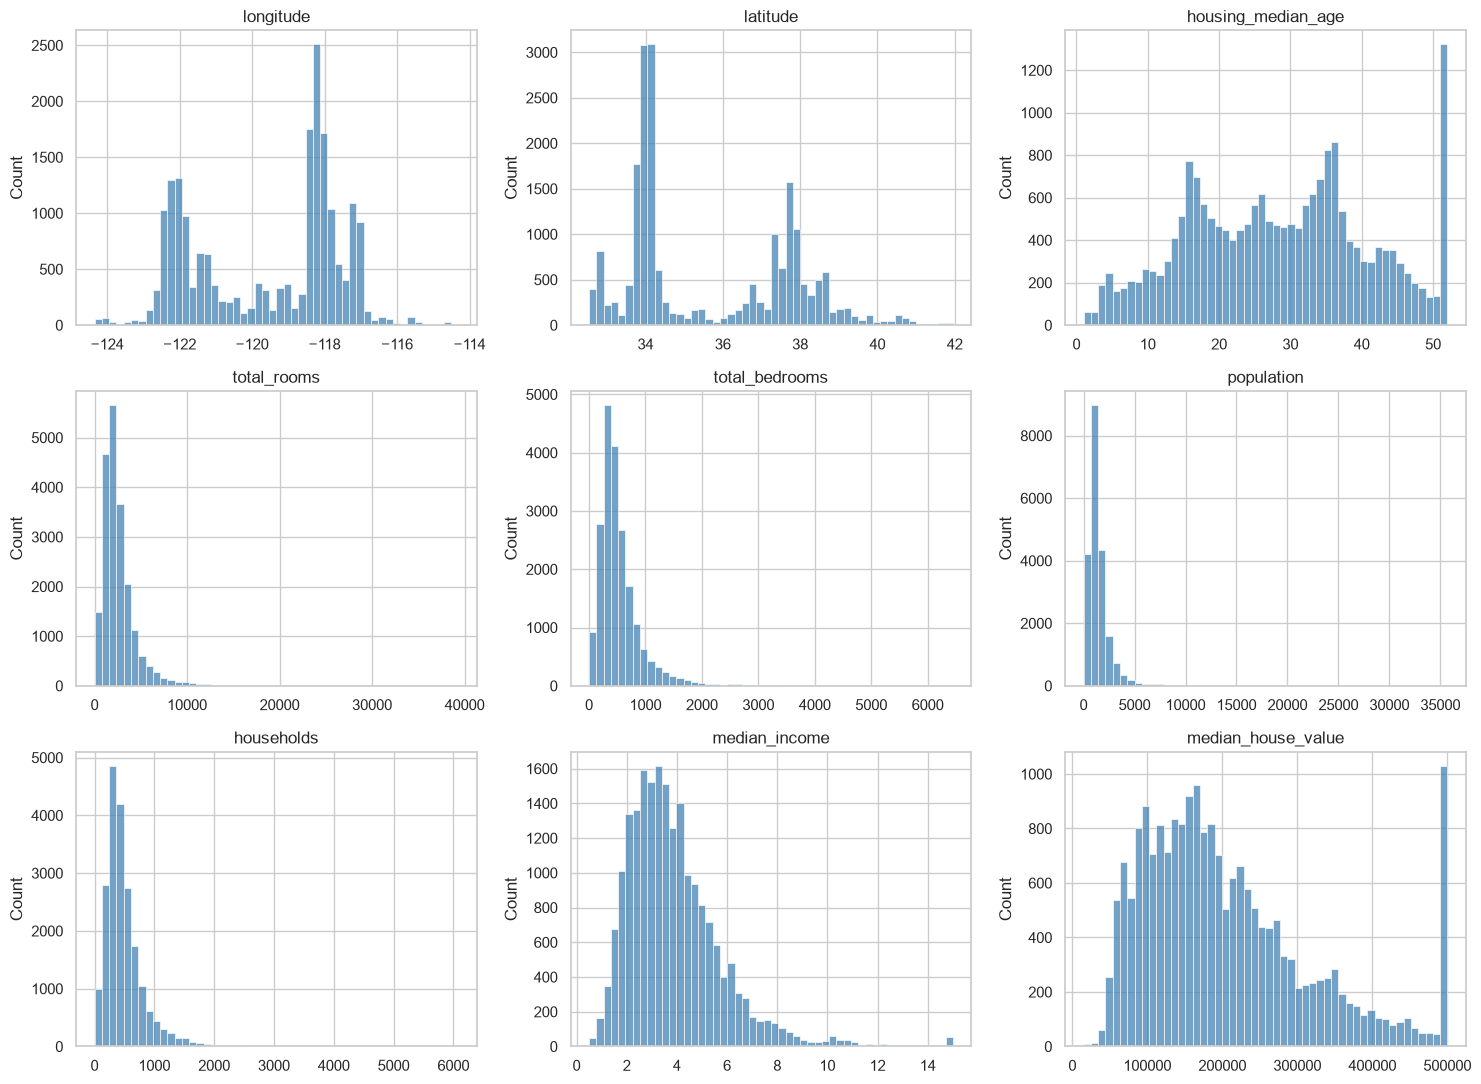

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c], bins=50, ax=ax, color="steelblue")
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

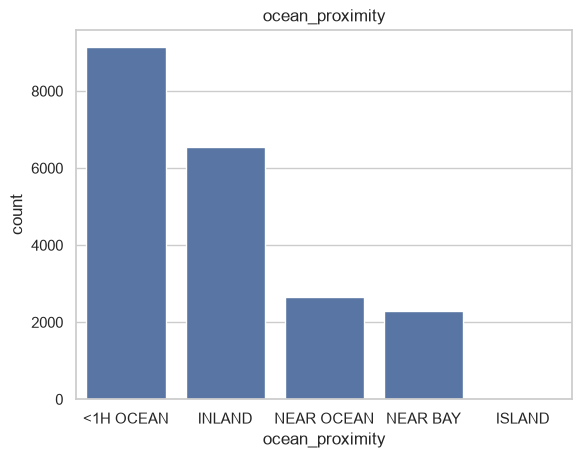

In [15]:
sns.countplot(data=df, x="ocean_proximity", order=df["ocean_proximity"].value_counts().index)
plt.title("ocean_proximity")
plt.show()

- `longitude` y `latitude` son **bimodales**: hay dos grandes aglomeraciones, el área de la Bahía
  (≈ 37.8°N, −122°) y Los Ángeles (≈ 34°N, −118°).
- Las variables de conteo y `median_income` tienen **asimetría a la derecha** (cola larga), lo que
  sugiere transformaciones logarítmicas o razones.
- `median_house_value` y `housing_median_age` muestran la **acumulación en el tope** (censura).
- Las escalas son muy distintas (de unidades a decenas de miles), así que hay que **escalar**.

### [Diagrama de caja](https://en.wikipedia.org/wiki/Box_plot)


### Diagrama de caja

![box](https://upload.wikimedia.org/wikipedia/commons/e/ed/Box_Plot_Picture.png)



### Interpretación de un diagrama de caja

- Desde el minimo al valor más bajo de la caja: primer cuartil, 25% de los datos
- Desde el valor más bajo de la caja hasta la mediana: segundo cuartil, 25% de los datos
- Desde la mediana hasta el valor mas alto de la caja : tercer cuartil, 25% de los datos
- Desde el valor mas alto de la caja hasta el máximo: Cuarto  cuartil, 25% de los datos


El rango intercuartil $IQR = Q_3-Q_1$ permite definir que datos pueden ser atípicos, basado en los siguientes limites:

$Max = Q3 + 1.5IQR$

$Min = Q1 - 1.5IQR$



El cuartil puede ser determinado como sigue:

Para calcular los cuartiles de una lista de números:

- Ordenar los números de menor a mayor.
- Calcular la posición de cada cuartil usando la fórmula: Q = a (N+1) / 4, donde Q es la posición del cuartil, a es el número del cuartil (1, 2 o 3), y N es el número total de datos.
- Si la posición del cuartil es un número entero, el valor del cuartil es el dato que está en esa posición.
- Si la posición del cuartil es un número decimal, el valor del cuartil se interpola usando la fórmula: Q = x + d (y - x), donde Q es el valor del cuartil, x es el dato anterior a la posición del cuartil, y es el dato posterior a la posición del cuartil, y d es la parte decimal de la posición del cuartil.


Veamos un ejemplo:

In [16]:
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)
print(len(T))
print(f"T sort:{Tsort}")
len(T)/4

24
T sort:[52 57 57 58 63 66 66 67 67 68 69 70 70 70 70 72 73 75 75 76 76 78 79 89]


6.0

In [17]:
def cuartil(datos, a):
    # Cuartil a (1, 2 o 3) con la regla del enunciado: posición Q = a(N+1)/4 (base 1) e interpolación
    x = np.sort(datos)
    pos = a * (len(x) + 1) / 4
    k, d = int(pos), pos - int(pos)
    if d == 0:
        return x[k - 1]
    return x[k - 1] + d * (x[k] - x[k - 1])

Q1, Q2, Q3 = (cuartil(T, a) for a in (1, 2, 3))
IQR = Q3 - Q1
print(f"Q1 = {Q1}, Q2 = {Q2}, Q3 = {Q3}, IQR = {IQR}")
print(f"Límites: [{Q1 - 1.5*IQR}, {Q3 + 1.5*IQR}]")
print("Atípicos:", T[(T < Q1 - 1.5*IQR) | (T > Q3 + 1.5*IQR)])
# la regla a(N+1)/4 es el método 'weibull' de numpy
print("numpy (weibull):", np.percentile(T, [25, 50, 75], method="weibull"))

Q1 = 66.0, Q2 = 70.0, Q3 = 75.0, IQR = 9.0
Límites: [52.5, 88.5]
Atípicos: [52 89]
numpy (weibull): [66. 70. 75.]


88.5
52.5


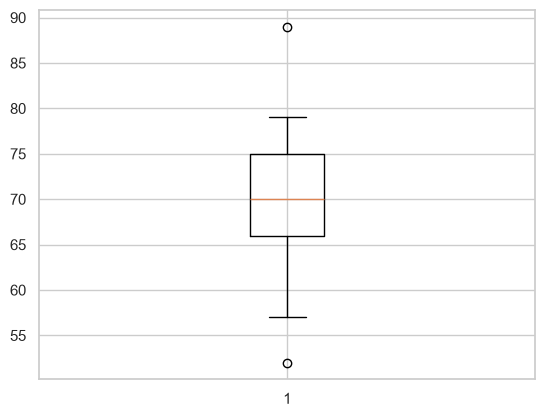

In [18]:
IQR=9
max_ = 75 + 1.5*IQR
min_ = 66 - 1.5*IQR
print(max_)
print(min_)
plt.boxplot(T)
plt.show()

Con $N = 24$ las posiciones son 6.25, 12.5 y 18.75: $Q_1 = 66$, $Q_2 = 70$, $Q_3 = 75$, por lo
que $IQR = 9$ y los límites son $[52.5,\ 88.5]$. Tanto **52 como 89 quedan fuera**: son los dos
puntos que `plt.boxplot` dibuja aislados. (Matplotlib usa otra regla de interpolación para los
cuartiles, pero con estos datos da el mismo resultado.)

8. Empleando el siguiente código realiza el gráfico boxplot,
```python
#draw boxplot
df.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))
#set title
plt.title('Boxplot for comparing price per living space for each city')
plt.show()
```

### Punto 8. Boxplot de `median_house_value` por `ocean_proximity`

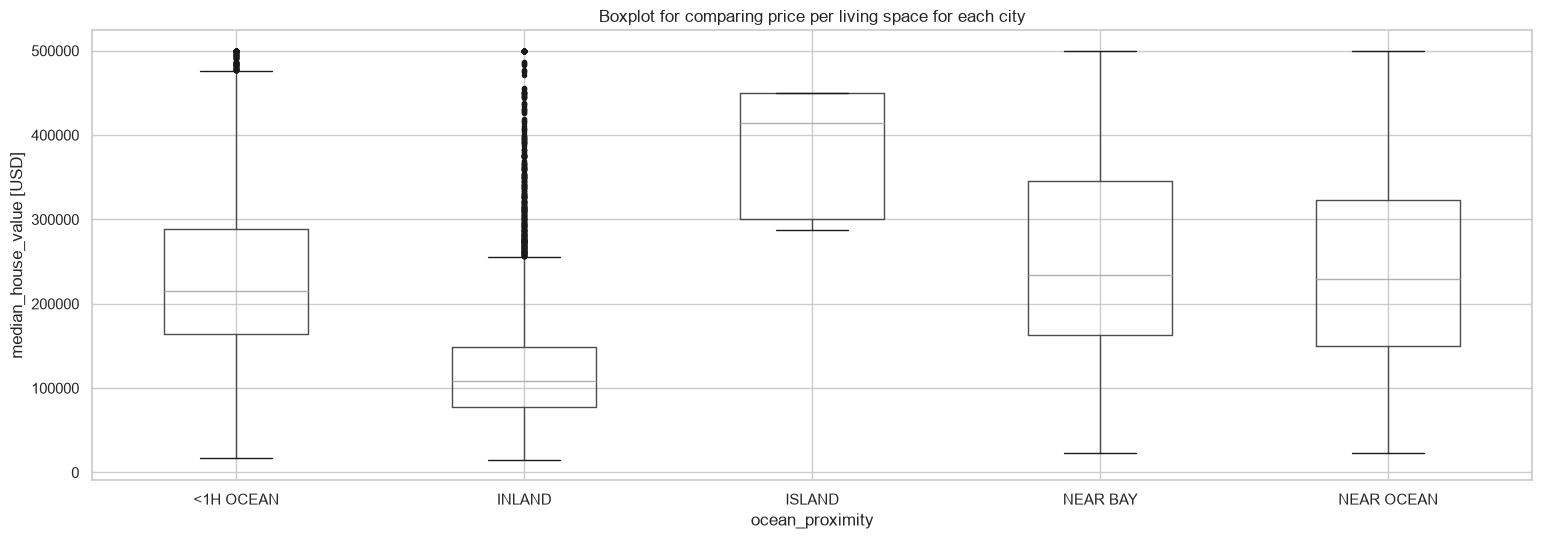

In [19]:
df.boxplot(column="median_house_value", by="ocean_proximity", sym="k.", figsize=(18, 6))
plt.title("Boxplot for comparing price per living space for each city")
plt.suptitle("")
plt.ylabel("median_house_value [USD]")
plt.show()

In [20]:
g = df.groupby("ocean_proximity")["median_house_value"]
pd.DataFrame({"mediana": g.median(),
              "IQR": g.quantile(0.75) - g.quantile(0.25),
              "distritos": g.size(),
              "atípicos (1.5 IQR)": g.apply(atipicos_iqr),
              "en el tope 500 001": g.apply(lambda s: (s >= 500001).sum())})

,mediana,IQR,distritos,atípicos (1.5 IQR),en el tope 500 001
ocean_proximity,,,,,
<1H OCEAN,214850.0,125000.0,9136,601,532
INLAND,108500.0,71450.0,6551,333,27
ISLAND,414700.0,150000.0,5,0,0
NEAR BAY,233800.0,183200.0,2290,0,194
NEAR OCEAN,229450.0,172750.0,2658,0,212


`INLAND` tiene la mediana más baja (108 500 USD) y la caja más compacta (IQR ≈ 71 000), con 333
atípicos por encima (distritos caros del interior). Las categorías costeras (`<1H OCEAN`,
`NEAR BAY`, `NEAR OCEAN`) tienen medianas parecidas entre sí (≈ 215 000-234 000), más altas y con
más dispersión (IQR ≈ 125 000-183 000). El tope de 500 001 afecta sobre todo a las costeras (532,
194 y 212 distritos) y casi nada a `INLAND` (27). `ISLAND` tiene solo 5 distritos, así que su caja
no es representativa. El título del código original habla de "price per living space" y de
"city", pero lo que se compara es el **valor medio de la vivienda por categoría de proximidad al mar**.

9. Determina la matrix de correlación.

### [Matrix de correlación](https://en.wikipedia.org/wiki/Correlation)

¿Como se determina la matrix de correlación?

![Matrix de correlación](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1920px-Correlation_examples2.svg.png)



```python
corr_matrix = df.corr()
corr_matrix

plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center=0)
plt.show()
```

### Punto 9. Matriz de correlación

La correlación de Pearson entre dos variables es la covarianza normalizada por las desviaciones:

$$
\rho_{XY} = \frac{\operatorname{cov}(X,Y)}{\sigma_X \sigma_Y}
= \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_i (x_i-\bar x)^2}\sqrt{\sum_i (y_i-\bar y)^2}} \in [-1, 1]
$$

La matriz de correlación es la **matriz de covarianzas de las variables estandarizadas**. Esta
observación se usa en el punto 23 (PCA). Mide solo relación **lineal**: en la figura del enunciado,
la última fila tiene $\rho = 0$ con dependencias claramente no lineales.

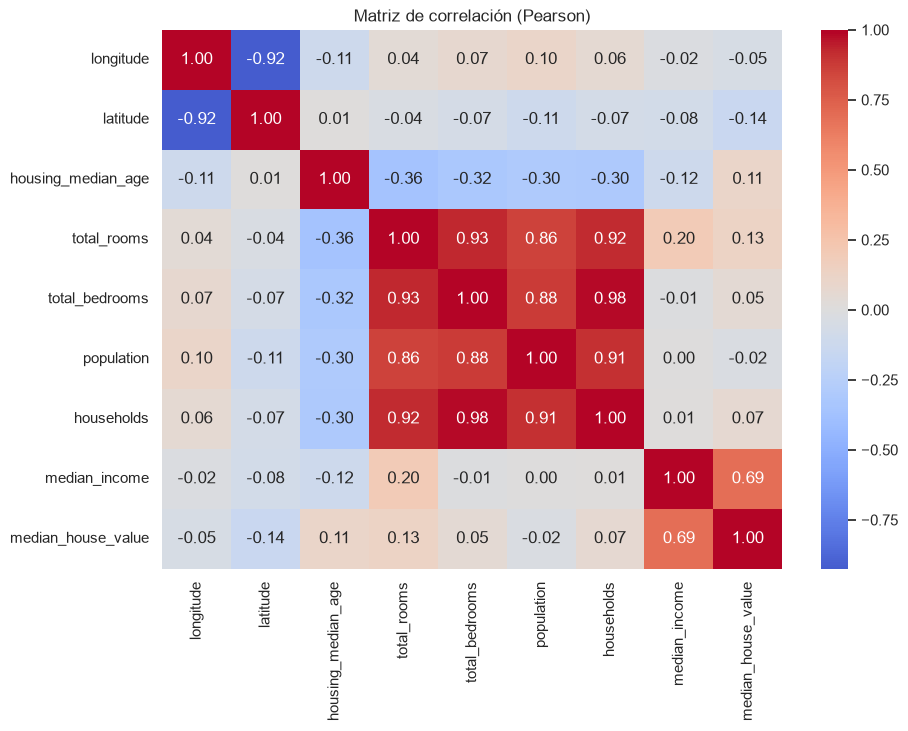

In [21]:
corr_matrix = df.corr(numeric_only=True)   # en pandas >= 2 hay que excluir la columna de texto

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación (Pearson)")
plt.show()

In [22]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

- El predictor lineal más fuerte del precio es `median_income` ($\rho \approx 0.69$). Las demás
  variables tienen correlación débil con el objetivo.
- Hay un **bloque de colinealidad** muy fuerte: `total_rooms`, `total_bedrooms`, `population` y
  `households` se correlacionan entre sí con $\rho \approx 0.86$-$0.98$. Las cuatro miden casi lo
  mismo, el **tamaño del distrito**.
- `latitude` y `longitude` tienen $\rho \approx -0.92$ porque California es un estado "diagonal"
  (de noroeste a sudeste).
- La correlación baja de `latitude` y `longitude` con el precio no significa que la ubicación no
  importe: su efecto es **no lineal** (dos polos costeros caros), como se ve en el punto 11.

10. con las columnas, realiza un grafico pairplot empleando seaborn  de python.
```python
cols = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
```

11. Realiza un scatter plot con la libreria sea born de python, el color del grafico puede ser empleado con la columna median_house_value

### Punto 10. Pairplot

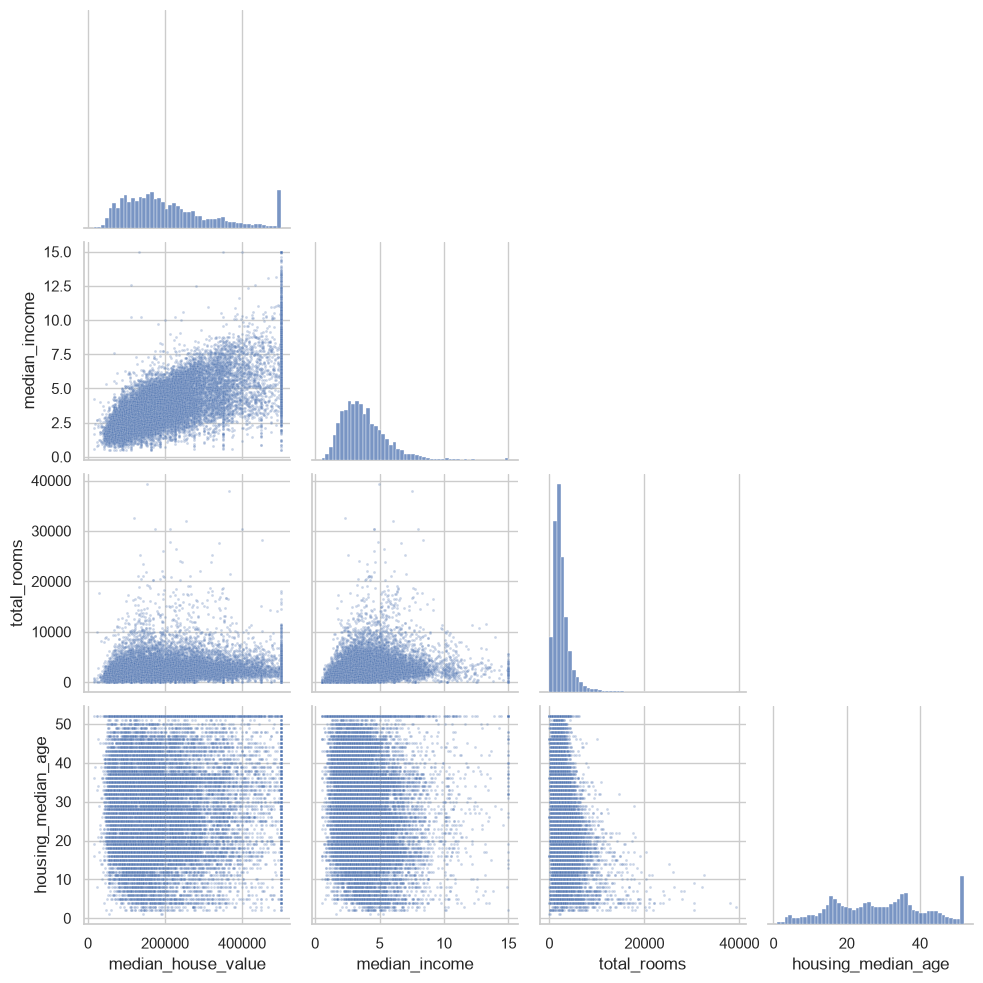

In [23]:
cols_pp = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
sns.pairplot(df[cols_pp], plot_kws={"s": 4, "alpha": 0.3}, diag_kws={"bins": 50}, corner=True)
plt.show()

- `median_house_value` frente a `median_income` es la relación más clara: creciente, aproximadamente
  lineal, con varianza que aumenta con el ingreso (**heterocedasticidad**) y una **línea horizontal
  en 500 001** (censura). Fuera del tope, los valores más repetidos son cifras redondas
  (137 500, 162 500, 112 500...; ver la tabla siguiente).
- `total_rooms` está concentrado cerca de 0 con una cola larga: en escala lineal casi no informa.
- `housing_median_age` no muestra una relación clara con el precio y tiene su propia acumulación en 52.

In [24]:
df["median_house_value"].value_counts().head(6)

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
225000.0     92
Name: count, dtype: int64

### Punto 11. Scatter plot geográfico coloreado por `median_house_value`

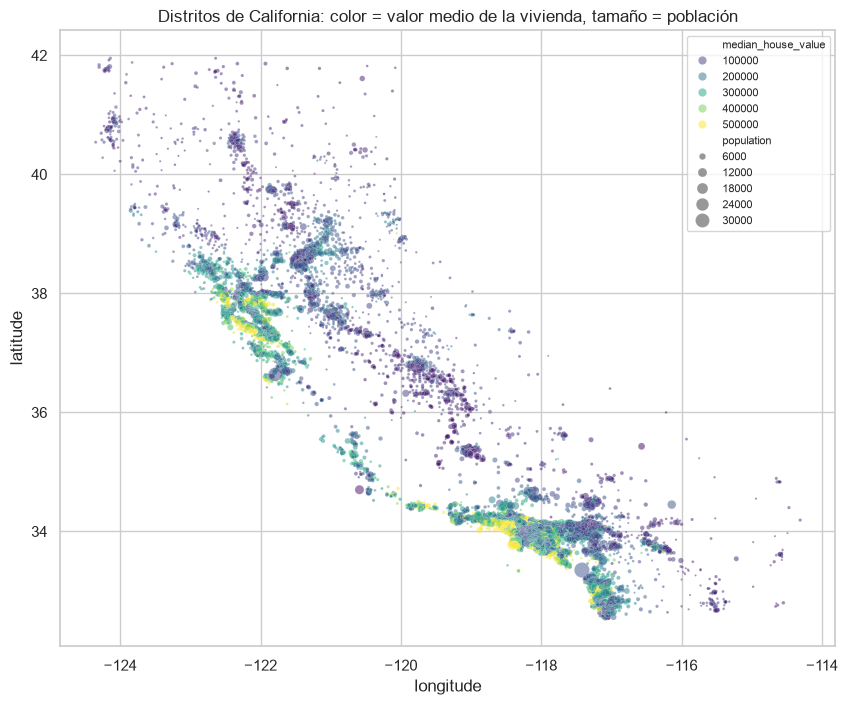

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="median_house_value",
                size="population", sizes=(2, 120), palette="viridis", alpha=0.5, ax=ax)
ax.set_title("Distritos de California: color = valor medio de la vivienda, tamaño = población")
ax.legend(loc="upper right", fontsize=8)
plt.show()

El mapa reproduce la forma de California. Los distritos más caros se concentran en la **costa**,
sobre todo en el área de la Bahía de San Francisco y en Los Ángeles/San Diego, y el precio cae al
alejarse del mar (valle central). Es un **gradiente espacial no lineal**: el precio no crece de
forma monótona con la latitud ni con la longitud. Por eso la correlación de Pearson del punto 9 lo
subestima y un modelo lineal en `longitude`/`latitude` no puede capturarlo bien. `ocean_proximity`
resume parte de ese efecto.

# 2.0 Preparación del data frame

## Evitar el data *Snooping bias*.

En algunos casos se sugiere dividir los datos en entrenamiento y test desde el principio dado que el cerebro puede sobreajustar el dataset y los resultados no significativos se pueden volver significativos. El procedimiento correcto es probar cualquier hipótesis en un conjunto de datos que no se utilizó para generar las hipótesis inicial.


## *Sampling bias*

Si el dataset es lo suficientemente grande un muestreo aleatorio de la muestra puede ser considerado, sin embargo si la muestra es pequena se debe garantizar homegeniedad en el dataset de entrenamiento.


Ejemplo:

Por ejemplo, la población de EE. UU. esta compuesto por un 51,3 % de mujeres y un 48,7 % de hombres, por lo que una encuesta bien realizada en EEUU
trata de mantener esta proporción en la muestra: 513 mujeres y 487 hombres. Esto se llama muestreo estratificado(stratified sampling): la población se divide en subgrupos homogéneos llamados estratos(strata), y se muestrea el número correcto de instancias de cada estrato para garantizar que el
El conjunto de prueba es representativo de la población general. Si usaran muestras puramente aleatorias, habría alrededor del 12% de posibilidades de muestrear un conjunto de prueba sesgado con menos del 49% de mujeres o más del 54% de mujeres. De cualquier manera, los resultados de la encuesta serían
significativamente sesgada.


12. ¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?


```python
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))

```


13. División del dataset en grupos:


La siguiente división puede ser realizada  basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa. Una posible solución al problema puede ser el siguiente:

```python
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


df.income_cat.hist()


```

La forma automatica de realizar la división puede ser la siguiente:

```python
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

```


Analiza las siguiente lineas de código y saca conclusiones referente a las proporciones del dataset.

```python
df["income_cat"].value_counts() / len(df)

strat_train_set["income_cat"].value_counts() / len(strat_train_set)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 7)

train_set["income_cat"].value_counts() / len(train_set)
```

un comparativo general puede ser estructurado de la siguente forma, analiza  los errores:

```python
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] =abs( 100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] =abs( 100 * compare_props["Stratified"] / compare_props["Overall"] - 100)
```

### Punto 12. ¿Es adecuada `train_test_split` para separar los datos?

In [26]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
print(len(train_set))
print(len(test_set))
print("ISLAND en test:", (test_set["ocean_proximity"] == "ISLAND").sum())

16512
4128
ISLAND en test: 1


`train_test_split` hace un **muestreo aleatorio simple**: baraja las filas y deja 80 % (16 512) para
entrenamiento y 20 % (4 128) para test. Con 20 640 distritos la muestra es grande y, en promedio,
representativa, pero no garantiza que **cada subgrupo importante** quede en la misma proporción en
ambos conjuntos. Si la variable que más explica el precio es `median_income`, una partición que
sub-represente por azar algún rango de ingreso da un test sesgado. Lo mismo pasa con categorías
pequeñas como `ISLAND`. Es aceptable, pero mejor es **estratificar** por la variable más relevante.

Además, en este notebook la exploración (sección 1) se hizo sobre **todo** el dataset, es decir,
antes de separar test. Eso es justamente el *data snooping* descrito arriba. A partir de aquí
todas las decisiones (imputación, escalado, PCA, hiperparámetros) se toman **solo con
entrenamiento**, y el test se usa una única vez, en el punto 25.

### Punto 13. División estratificada por categorías de ingreso

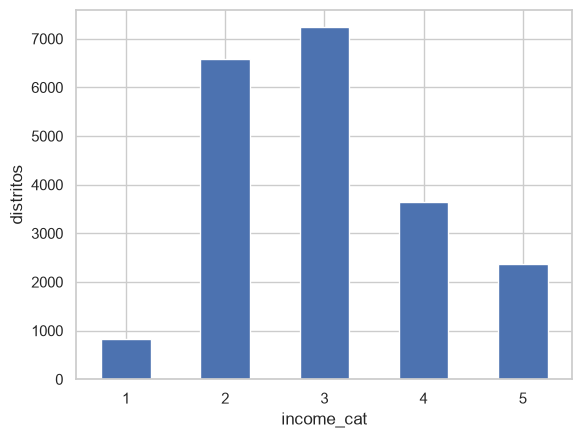

In [27]:
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1, 2, 3, 4, 5])
df["income_cat"].value_counts().sort_index().plot.bar(rot=0)
plt.xlabel("income_cat")
plt.ylabel("distritos")
plt.show()

In [28]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.iloc[train_index].copy()   # split devuelve posiciones -> iloc
    strat_test_set = df.iloc[test_index].copy()

print(len(strat_train_set), len(strat_test_set))

16512 4128


In [29]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = abs(100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] = abs(100 * compare_props["Stratified"] / compare_props["Overall"] - 100)
compare_props.round(4)

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.0398,0.0400,0.0402,0.9732,0.3650
2,0.3188,0.3188,0.3244,1.7323,0.0152
3,0.3506,0.3505,0.3585,2.2664,0.0138
4,0.1763,0.1764,0.1674,5.0563,0.0275
5,0.1144,0.1143,0.1095,4.3184,0.0847


El test estratificado reproduce las proporciones de `income_cat` con un error relativo cercano a
**0 %** en todas las categorías. El aleatorio se desvía más: ≈ 5 % en la categoría 4 y ≈ 4 % en la 5
con esta semilla.

Una sola semilla puede ser buena o mala por suerte, así que se repite el experimento con 200
semillas y se mira el peor error relativo de cada partición:

       Random  Stratified
count  200.00      200.00
mean     6.53        0.36
std      3.55        0.00
min      0.52        0.36
25%      3.98        0.36
50%      5.72        0.36
75%      8.39        0.36
max     22.14        0.36


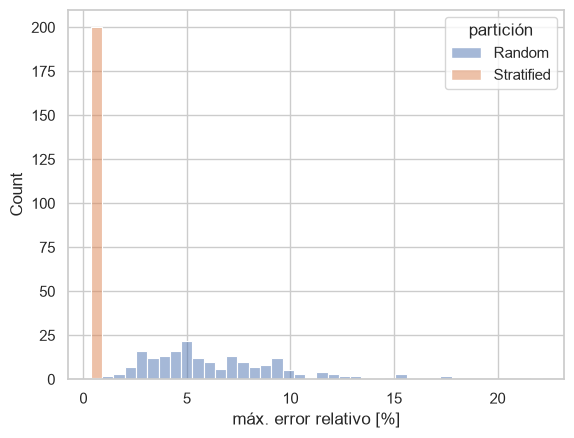

In [30]:
overall = income_cat_proportions(df)
errores = {"Random": [], "Stratified": []}
for s in range(200):
    _, te_r = train_test_split(df, test_size=0.2, random_state=s)
    _, te_s = next(StratifiedShuffleSplit(1, test_size=0.2, random_state=s).split(df, df["income_cat"]))
    errores["Random"].append((100 * abs(income_cat_proportions(te_r) / overall - 1)).max())
    errores["Stratified"].append((100 * abs(income_cat_proportions(df.iloc[te_s]) / overall - 1)).max())

errores = pd.DataFrame(errores)
print(errores.describe().round(2))
sns.histplot(errores.melt(var_name="partición", value_name="máx. error relativo [%]"),
             x="máx. error relativo [%]", hue="partición", bins=40)
plt.show()

**Conclusión.** Con muestreo aleatorio el peor error relativo en alguna categoría de ingreso tiene
una mediana de ≈ 6 %, suele estar entre 4 % y 8 % y llega hasta ≈ 22 % con alguna semilla. Con la
estratificación es siempre ≈ 0.4 %, el mínimo que permite el redondeo de los conteos. La
estratificación garantiza que el test tenga la **misma composición de ingresos** que la población,
y el ingreso es la variable que más pesa en el precio. Por eso se usan `strat_train_set` y
`strat_test_set` en el resto del laboratorio.

`income_cat` solo sirve para partir los datos. Se elimina para que no entre al modelo como variable
(sería una versión discretizada y redundante de `median_income`).

In [31]:
for s in (strat_train_set, strat_test_set, df):
    s.drop("income_cat", axis=1, inplace=True)

df_train = strat_train_set.copy()      # a partir de aquí se trabaja SOLO con entrenamiento
df_test = strat_test_set.copy()        # el test queda aislado hasta el punto 25

13. Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:
```python
df_train["rooms_per_household"] = df_train["total_rooms"]/df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"]/df_train["total_rooms"]
df_train["population_per_household"]=df_train["population"]/df_train["households"]
```




# Limpieza de datos

Lo que sigue son códigos que pueden servir para limpiar los datos.

```python

df.isnull().sum()


#df_train.dropna(subset=["total_bedrooms"]) #Eliminar los nan
#df_train.drop("total_bedrooms", axis=1)  # Eliminar la columna
median = df_train["total_bedrooms"].median()
q=df_train["total_bedrooms"].fillna(median).copy()


q=pd.DataFrame(q)

q.isnull().sum()

```

##imputer

Forma automática para tratar los datos (Asegurate de trabajar con las columnas numéricas):


```python
from sklearn.impute import SimpleImputer
#imputer = Imputer(strategy="median")

df_train_num = df_train.drop("ocean_proximity", axis=1)

imp_mean = SimpleImputer( strategy='mean')

imp_mean.fit(df_train_num)

imp_mean.statistics_
```

14. Compara las siguientes variables:
```python
imp_mean.statistics_
df_train_num.median()
```


```python
Constuye la matriz de características:

X = imp_mean.transform(df)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)
```


# Manejo de texto y atributos categóricos
15.  ¿Qué realizan las siguientes lineas de código?

```
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]]
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.join(df_cat_1hot)
```


# Escalamiento de variables

16. Las variables pueden ser escaladas como sigue:

```python

cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)

```


17. Para todos los pasos anteriores, contruye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estractificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.

1. ¿que puede concluir respecto al modelo empleado?
2. ¿El modelo de regresión lineal es valido para lo construido,
3. ¿qué informacion nos da el score?
4. ¿Puede ser ajustado a otro modelo?
5. ¿Como puede autmatizar todo el proceso empleando pipelines?

### Punto 13 (nuevas variables). Feature engineering

In [32]:
df_train_fe = df_train.copy()          # copia para explorar sin alterar df_train
df_train_fe["rooms_per_household"] = df_train_fe["total_rooms"] / df_train_fe["households"]
df_train_fe["bedrooms_per_room"] = df_train_fe["total_bedrooms"] / df_train_fe["total_rooms"]
df_train_fe["population_per_household"] = df_train_fe["population"] / df_train_fe["households"]

df_train_fe.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False).round(3)

median_house_value          1.000
median_income               0.687
rooms_per_household         0.146
total_rooms                 0.135
housing_median_age          0.114
households                  0.065
total_bedrooms              0.048
population_per_household   -0.022
population                 -0.027
longitude                  -0.047
latitude                   -0.143
bedrooms_per_room          -0.260
Name: median_house_value, dtype: float64

Las razones **normalizan por tamaño del distrito** y describen la vivienda típica.
`bedrooms_per_room` ($\rho \approx -0.26$) se correlaciona con el precio más que cualquiera de los
totales: una proporción baja de dormitorios sugiere viviendas con más espacios que no son
dormitorios, es decir, viviendas más grandes. `rooms_per_household` también supera a `total_rooms`. En el punto 23 se
revisa si esta información la capturan o no las componentes principales.

# Limpieza de datos

In [33]:
print(df_train.isnull().sum(), "\n")

median = df_train["total_bedrooms"].median()
q = df_train["total_bedrooms"].fillna(median).copy()
q = pd.DataFrame(q)
print("NaN tras rellenar con la mediana:", q.isnull().sum().item())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64 

NaN tras rellenar con la mediana: 0


Las tres alternativas del enunciado: `dropna` elimina ~1 % de las filas, `drop` elimina la columna
completa (perdiendo información útil) y `fillna(median)` conserva todo. Se usa la tercera, automatizada
con `SimpleImputer`.

### Punto 14. `SimpleImputer`: media frente a mediana

In [34]:
# Se excluyen la columna de texto y el objetivo: el imputador solo debe ver las características
df_train_num = df_train.drop(["ocean_proximity", "median_house_value"], axis=1)

imp_mean = SimpleImputer(strategy="mean")
imp_mean.fit(df_train_num)

pd.DataFrame({"imp_mean.statistics_": imp_mean.statistics_,
              "df_train_num.mean()": df_train_num.mean(),
              "df_train_num.median()": df_train_num.median()},
             index=df_train_num.columns).round(3)

,imp_mean.statistics_,df_train_num.mean(),df_train_num.median()
longitude,-119.576,-119.576,-118.510
latitude,35.639,35.639,34.260
housing_median_age,28.653,28.653,29.000
total_rooms,2622.540,2622.540,2119.000
total_bedrooms,534.915,534.915,433.000
population,1419.687,1419.687,1164.000
households,497.012,497.012,408.000
median_income,3.876,3.876,3.542


`imp_mean.statistics_` coincide exactamente con `df_train_num.mean()` (calculada ignorando NaN),
**no** con la mediana. En las variables asimétricas (`total_bedrooms`, `population`, etc.) la media
es bastante mayor que la mediana porque los distritos muy grandes la arrastran. Para
`total_bedrooms` la media es ≈ 535 y la mediana 433. La mediana es **robusta a atípicos** y
representa mejor al distrito típico, así que se usa `SimpleImputer(strategy="median")`.

La mediana se calcula **solo con entrenamiento** y luego se aplica al test. Calcularla con todo el
dataset filtraría información del test.

In [35]:
imputer = SimpleImputer(strategy="median").fit(df_train_num)

# Matriz de características. El enunciado escribe imputer.transform(df), pero df tiene la columna
# de texto y el objetivo: hay que transformar las MISMAS columnas con las que se ajustó.
X = imputer.transform(df_train_num)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns, index=df_train_num.index)
print(housing_tr.isnull().sum().sum(), "NaN restantes")
housing_tr.head()

0 NaN restantes


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


# Manejo de texto y atributos categóricos

### Punto 15. ¿Qué realizan estas líneas? (`OneHotEncoder`)

In [36]:
print(df_train["ocean_proximity"].unique())
housing_cat = df_train[["ocean_proximity"]]       # doble corchete: DataFrame 2D, como exige sklearn

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot[:5])
print(cat_encoder.categories_)

df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns=cat_encoder.categories_[0], index=df_train.index)
housing_tr_ = housing_tr.join(df_cat_1hot)
housing_tr_.head()

<StringArray>
['INLAND', 'NEAR OCEAN', '<1H OCEAN', 'NEAR BAY', 'ISLAND']
Length: 5, dtype: str
[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]]
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,0.0,1.0,0.0,0.0,0.0
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,0.0,0.0,0.0,0.0,1.0
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,0.0,1.0,0.0,0.0,0.0
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,0.0,0.0,0.0,0.0,1.0
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,1.0,0.0,0.0,0.0,0.0


1. `unique()` lista las 5 categorías de texto.
2. `OneHotEncoder` aprende esas categorías (`fit`) y reemplaza la columna de texto por **5 columnas
   binarias** (*dummies*), una por categoría, con un 1 en la que corresponde al distrito y 0 en las
   demás (`transform`). `categories_` guarda el orden de las columnas. `sparse_output=False`
   devuelve un arreglo denso en vez de una matriz dispersa.
3. Se arma un DataFrame con esas columnas y se **une** (`join`) a las variables numéricas imputadas.

**¿Por qué one-hot y no 0, 1, 2, 3, 4?** `ocean_proximity` es nominal. Un código entero le impondría
un orden y distancias inexistentes (por ejemplo, que `ISLAND` está "más lejos" de `<1H OCEAN` que
`INLAND`), y un modelo lineal las interpretaría literalmente.

Dos detalles prácticos:
- `join` alinea por **índice**. `df_train` conserva el índice original barajado, así que el
  DataFrame de las dummies se crea con ese mismo índice. Si uno de los dos tuviera índice 0..n-1 y el
  otro no, el `join` mezclaría filas en silencio.
- Las 5 dummies suman siempre 1, así que junto con el intercepto son **perfectamente colineales**
  (*trampa de las variables dummy*). Esto vuelve a aparecer en los coeficientes (puntos 18 y 24).

# Escalamiento de variables

### Punto 16. `MinMaxScaler`

In [37]:
cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
        "total_bedrooms", "population", "households", "median_income",
        "<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"]

housing_scale = housing_tr_[cols]

scaler = MinMaxScaler()
scaler.fit(housing_scale)
X = scaler.transform(housing_scale)

housing_prepared = pd.DataFrame(X, columns=housing_scale.columns, index=housing_scale.index)
housing_prepared.describe().loc[["min", "max", "mean"]].round(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
min,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.0,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.00,1.000,1.000,1.000,1.000,1.0,1.000,1.000
mean,0.476,0.329,0.542,0.067,0.086,0.04,0.092,0.233,0.441,0.319,0.0,0.112,0.129


`MinMaxScaler` lleva cada columna a $[0,1]$ con $x' = (x - x_{\min})/(x_{\max} - x_{\min})$.
Las dummies no cambian (ya eran 0/1). En las variables de conteo la **media queda entre 0.04 y 0.09**:
como el máximo es un distrito atípico enorme, casi todos los datos quedan aplastados cerca de cero.
Esta debilidad importa en el punto 23.

### Punto 17. Preparación ordenada y regresión lineal

Se repiten en orden los pasos anteriores, ahora **ajustando cada transformación solo con
entrenamiento** y aplicándola igual al test:

1. División estratificada (punto 13): `df_train`, `df_test`.
2. Limpieza: imputación por mediana de las numéricas.
3. Texto: one-hot de `ocean_proximity` (con `handle_unknown="ignore"` por si el test trae una
   categoría que no estaba en entrenamiento).
4. Escalamiento `MinMaxScaler` sobre las 13 columnas de `cols`.
5. Se añade la etiqueta `median_house_value` para obtener `housing_train` y `housing_test`.

In [38]:
target = "median_house_value"
num_features = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income"]

def preparar(train, test, scaler):
    # Ajusta imputador, codificador y escalador con train y transforma train y test por igual
    imp = SimpleImputer(strategy="median").fit(train[num_features])
    enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(train[["ocean_proximity"]])

    def transformar(d):
        num = pd.DataFrame(imp.transform(d[num_features]), columns=num_features, index=d.index)
        cat = pd.DataFrame(enc.transform(d[["ocean_proximity"]]),
                           columns=enc.categories_[0], index=d.index)
        return num.join(cat)[cols]

    Xtr, Xte = transformar(train), transformar(test)
    scaler.fit(Xtr)
    salida = []
    for X_, d in ((Xtr, train), (Xte, test)):
        h = pd.DataFrame(scaler.transform(X_), columns=cols, index=d.index)
        h[target] = d[target]
        salida.append(h)
    return salida

housing_train, housing_test = preparar(df_train, df_test, MinMaxScaler())
print(housing_train.shape, housing_test.shape)
housing_train.head()

(16512, 14) (4128, 14)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
12655,0.287849,0.635494,0.549020,0.098362,0.128061,0.062614,0.131441,0.115426,0.0,1.0,0.0,0.0,0.0,72100.0
15502,0.709163,0.058448,0.117647,0.135168,0.137403,0.056392,0.143017,0.402574,0.0,0.0,0.0,0.0,1.0,279600.0
2908,0.528884,0.300744,0.843137,0.041003,0.049613,0.018610,0.055639,0.163798,0.0,1.0,0.0,0.0,0.0,82700.0
14053,0.719124,0.022317,0.450980,0.047591,0.083280,0.025085,0.089806,0.119067,0.0,0.0,0.0,0.0,1.0,112500.0
20496,0.562749,0.184910,0.509804,0.089790,0.103737,0.051403,0.107916,0.275617,1.0,0.0,0.0,0.0,0.0,238300.0


In [39]:
X_train, y_train = housing_train[cols], housing_train[target]

lin_reg = LinearRegression().fit(X_train, y_train)
pred_train = lin_reg.predict(X_train)

cv_lin = cross_validate(LinearRegression(), X_train, y_train, cv=cv5,
                        scoring=("r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"))
base = cross_val_score(DummyRegressor(strategy="mean"), X_train, y_train, cv=cv5,
                       scoring="neg_root_mean_squared_error")

print(f"score (R²) en entrenamiento: {lin_reg.score(X_train, y_train):.4f}")
print(f"RMSE entrenamiento:          {mean_squared_error(y_train, pred_train) ** 0.5:,.0f} USD")
print(f"R² validación cruzada (5):   {cv_lin['test_r2'].mean():.4f} ± {cv_lin['test_r2'].std():.4f}")
print(f"RMSE validación cruzada:     {-cv_lin['test_neg_root_mean_squared_error'].mean():,.0f} USD")
print(f"MAE validación cruzada:      {-cv_lin['test_neg_mean_absolute_error'].mean():,.0f} USD")
print(f"RMSE modelo trivial (media): {-base.mean():,.0f} USD   (desv. estándar de y)")

score (R²) en entrenamiento: 0.6438
RMSE entrenamiento:          69,051 USD
R² validación cruzada (5):   0.6417 ± 0.0083
RMSE validación cruzada:     69,241 USD
MAE validación cruzada:      49,980 USD
RMSE modelo trivial (media): 115,699 USD   (desv. estándar de y)


intercepto = 273,079
suma de coeficientes de las 5 dummies = 0


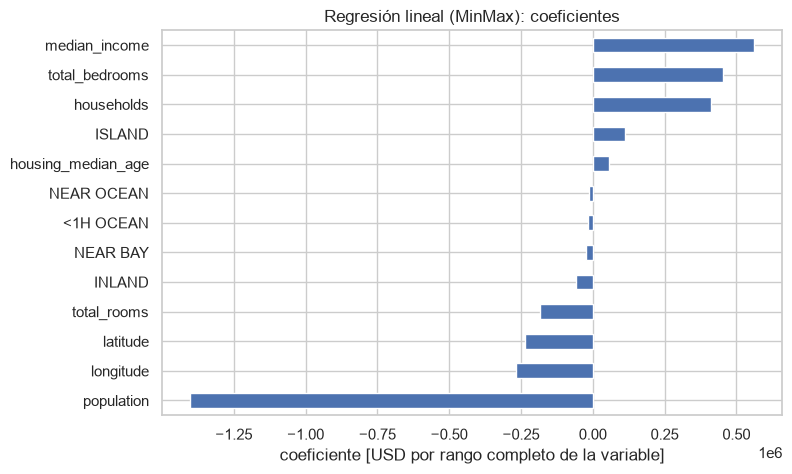

longitude             -266620.0
latitude              -237756.0
housing_median_age      55661.0
total_rooms           -184259.0
total_bedrooms         452428.0
population           -1401276.0
households             412021.0
median_income          561301.0
<1H OCEAN              -18139.0
INLAND                 -57836.0
ISLAND                 112926.0
NEAR BAY               -22518.0
NEAR OCEAN             -14433.0
dtype: float64

In [40]:
coef_lin = pd.Series(lin_reg.coef_, index=cols)
print(f"intercepto = {lin_reg.intercept_:,.0f}")
print(f"suma de coeficientes de las 5 dummies = {coef_lin.iloc[8:].sum():,.0f}")
coef_lin.sort_values().plot.barh(figsize=(8, 5))
plt.xlabel("coeficiente [USD por rango completo de la variable]")
plt.title("Regresión lineal (MinMax): coeficientes")
plt.show()
coef_lin.round(0)

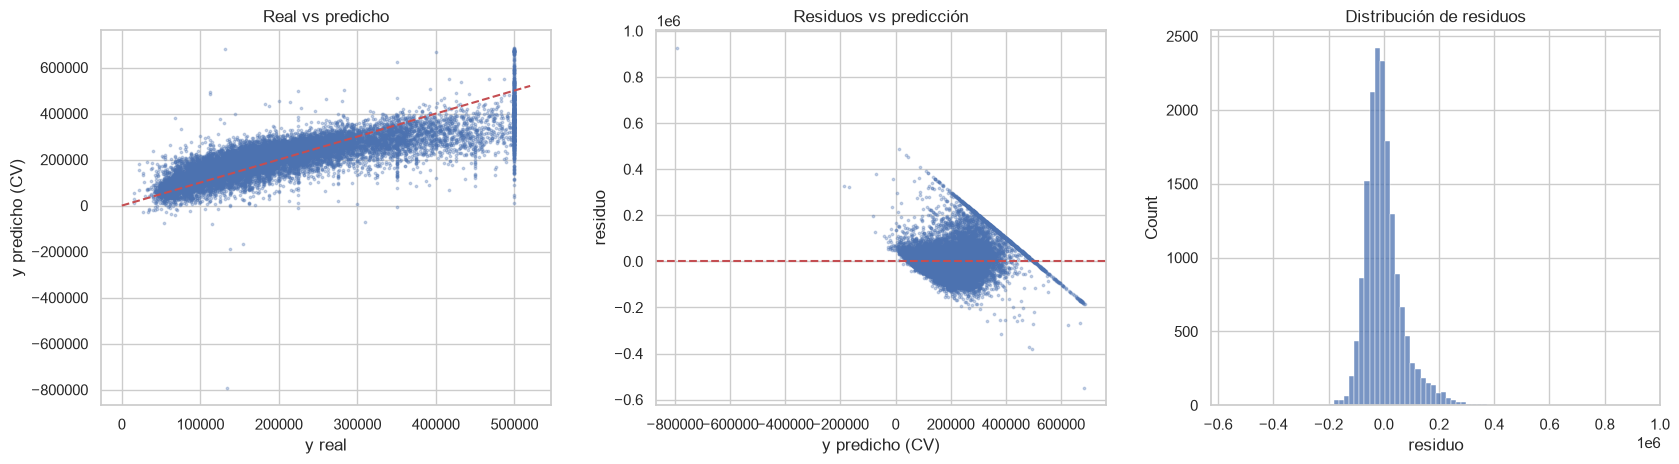

Predicciones negativas: 30   predicciones > 500 001: 143


In [41]:
pred_cv = cross_val_predict(LinearRegression(), X_train, y_train, cv=cv5)
res = y_train - pred_cv

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].scatter(y_train, pred_cv, s=3, alpha=0.3)
axes[0].plot([0, 5.2e5], [0, 5.2e5], "r--")
axes[0].set(xlabel="y real", ylabel="y predicho (CV)", title="Real vs predicho")
axes[1].scatter(pred_cv, res, s=3, alpha=0.3)
axes[1].axhline(0, color="r", ls="--")
axes[1].set(xlabel="y predicho (CV)", ylabel="residuo", title="Residuos vs predicción")
sns.histplot(res, bins=80, ax=axes[2])
axes[2].set(title="Distribución de residuos", xlabel="residuo")
plt.tight_layout()
plt.show()
print(f"Predicciones negativas: {(pred_cv < 0).sum()}   predicciones > 500 001: {(pred_cv > 500001).sum()}")

In [42]:
from sklearn.neighbors import NearestNeighbors

res_np = res.to_numpy()
print("Desv. estándar del residuo por quintil de la predicción (USD):")
print(pd.Series(res_np).groupby(pd.qcut(pred_cv, 5), observed=True).std().round(0).to_string())
print(f"\nAsimetría de los residuos: {res.skew():.2f}")

coords = df_train[["latitude", "longitude"]]
vecino = NearestNeighbors(n_neighbors=2).fit(coords).kneighbors(coords)[1][:, 1]
print(f"Correlación residuo - residuo del vecino más cercano: {np.corrcoef(res_np, res_np[vecino])[0, 1]:.2f}")
print(f"Distritos en el tope 500 001 subestimados (residuo > 0): {(res_np[y_train.to_numpy() >= 500001] > 0).mean():.0%}")

Desv. estándar del residuo por quintil de la predicción (USD):
(-793565.853, 128438.805]    51754.0
(128438.805, 179932.685]     56540.0
(179932.685, 226405.162]     64853.0
(226405.162, 275564.995]     77071.0
(275564.995, 686955.276]     84334.0

Asimetría de los residuos: 1.29
Correlación residuo - residuo del vecino más cercano: 0.60
Distritos en el tope 500 001 subestimados (residuo > 0): 83%


#### Puntos 18-22. Preguntas sobre el modelo

En el enunciado estas cinco preguntas aparecen numeradas del 1 al 5 al final del punto 17. Los
puntos 23-25 se refieren a ellas como puntos 18 a 22, así que se numeran así.

**18. ¿Qué se puede concluir respecto al modelo empleado?**

La regresión lineal con las 13 variables explica alrededor del **64 % de la varianza** del valor de
la vivienda ($R^2 \approx 0.64$) con un error típico (RMSE) de **≈ 69 000 USD**. El modelo trivial
que siempre predice la media tiene un RMSE de ≈ 115 000. El modelo aprende algo, pero el error es
grande frente a un precio mediano de ≈ 180 000 USD.

El $R^2$ de entrenamiento y el de validación cruzada son prácticamente iguales, así que **no hay
sobreajuste**. El problema es el contrario: **subajuste (alto sesgo)**. El modelo es demasiado
simple para la estructura de los datos. Los gráficos lo muestran: las predicciones se abren en
abanico, hay predicciones **negativas** e imposibles, y el tope de 500 001 aparece como una línea
vertical que el modelo no reproduce.

**19. ¿Es válido el modelo de regresión lineal para lo construido?**

Como **predictor de referencia (baseline)**, sí. Como modelo **inferencial** (interpretar sus
coeficientes como efectos), no, porque varios supuestos fallan:

- **Linealidad:** el efecto de la ubicación es claramente no lineal (punto 11).
- **Homocedasticidad:** la desviación estándar del residuo pasa de ≈ 52 000 USD en el quintil de
  predicciones más bajas a ≈ 84 000 en el más alto (abanico).
- **Normalidad de residuos:** la distribución es asimétrica (asimetría ≈ 1.3, cola derecha). Una
  causa visible es la censura: el 83 % de los distritos en el tope quedan subestimados.
- **Independencia:** el residuo de un distrito y el de su vecino geográfico más cercano tienen
  correlación ≈ 0.6 (autocorrelación espacial). Los errores no son independientes.
- **No colinealidad:** el bloque `total_rooms` / `total_bedrooms` / `population` / `households`
  tiene $\rho$ entre 0.86 y 0.98 y las 5 dummies son exactamente colineales con el intercepto. Los coeficientes
  resultan inestables: `total_rooms` sale **negativo** y `total_bedrooms` **positivo y enorme**, cosa
  que no tiene sentido físico, y las dummies toman valores arbitrarios que solo se compensan con el
  intercepto. La matriz $X^TX$ es singular, así que `LinearRegression` devuelve la solución de mínima
  norma (vía pseudoinversa) entre infinitas posibles.

**20. ¿Qué información nos da el `score`?**

`score` es el coeficiente de determinación:

$$R^2 = 1 - \frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}$$

Mide qué fracción de la varianza de $y$ explica el modelo frente a predecir siempre la media
($R^2=0$). $R^2 = 1$ sería un ajuste perfecto y $R^2 < 0$ indicaría un modelo peor que la media.
Calculado **sobre los datos de entrenamiento** es optimista: solo dice cuánto se ajusta a lo que ya
vio. Calculado en validación cruzada (o en test) estima la capacidad de **generalización**. El $R^2$
no tiene unidades. Para hablar del error en dólares hay que mirar RMSE o MAE.

**21. ¿Puede ser ajustado a otro modelo?** Sí. Como el diagnóstico es subajuste, hacen falta modelos
más flexibles. Una prueba rápida con validación cruzada sobre los mismos datos de entrenamiento:

In [43]:
modelos = {
    "Regresión lineal": LinearRegression(),
    "Árbol de decisión": DecisionTreeRegressor(random_state=SEED),
    "Random forest": RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
}
filas = []
for nombre, m in modelos.items():
    r = cross_validate(m, X_train, y_train, cv=cv5, return_train_score=True,
                       scoring="neg_root_mean_squared_error", n_jobs=1)
    filas.append({"modelo": nombre,
                  "RMSE entrenamiento": -r["train_score"].mean(),
                  "RMSE validación (CV)": -r["test_score"].mean()})
pd.DataFrame(filas).set_index("modelo").round(0)

,RMSE entrenamiento,RMSE validación (CV)
modelo,,
Regresión lineal,69030.0,69241.0
Árbol de decisión,-0.0,69166.0
Random forest,18700.0,50120.0


- El **árbol de decisión** sin restricciones memoriza el entrenamiento (RMSE = 0) y valida igual
  que la regresión lineal (≈ 69 000): es el extremo opuesto, **sobreajuste**. Su capacidad extra se
  gasta en memorizar ruido.
- El **random forest** promedia muchos árboles, reduce la varianza y baja el RMSE de validación a
  ≈ 50 000 USD (≈ 28 % menos error que la regresión lineal).

Sí se puede ajustar otro modelo, y mejor. El costo es la interpretabilidad. El punto 24 responde la
pregunta dentro de la familia lineal (polinomios + regularización), que conserva un modelo explícito.

**22. ¿Cómo automatizar todo el proceso con *pipelines*?**

Con `Pipeline` y `ColumnTransformer` todo el preprocesamiento se vuelve **un solo estimador** que
recibe el DataFrame crudo:

In [44]:
def preprocesador(scaler):
    numerico = Pipeline([("imputar", SimpleImputer(strategy="median")),
                         ("escalar", scaler)])
    return ColumnTransformer([
        ("num", numerico, num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["ocean_proximity"]),
    ])

pipe_lin = Pipeline([("prep", preprocesador(MinMaxScaler())),
                     ("modelo", LinearRegression())])

X_train_raw = df_train.drop(target, axis=1)     # DataFrame crudo, con NaN y texto
y_train_raw = df_train[target]

r_pipe = cross_validate(pipe_lin, X_train_raw, y_train_raw, cv=cv5, scoring=("r2", "neg_root_mean_squared_error"))
print(f"Pipeline  R² CV = {r_pipe['test_r2'].mean():.4f}   RMSE CV = {-r_pipe['test_neg_root_mean_squared_error'].mean():,.0f}")
print(f"Manual    R² CV = {cv_lin['test_r2'].mean():.4f}   RMSE CV = {-cv_lin['test_neg_root_mean_squared_error'].mean():,.0f}")
pipe_lin

Pipeline  R² CV = 0.6417   RMSE CV = 69,241
Manual    R² CV = 0.6417   RMSE CV = 69,241


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

El resultado coincide con el procedimiento manual del punto 17, pero el pipeline tiene ventajas:

- **Sin fuga de información en validación cruzada.** En el manual, el imputador y el escalador se
  ajustaron con *todo* `df_train` antes de la CV, así que cada pliegue de validación ya "había visto"
  sus medianas y máximos. El pipeline vuelve a ajustar el preprocesamiento **dentro de cada pliegue**.
  Aquí no cambia el resultado (coinciden hasta el cuarto decimal), pero con preprocesamientos que
  dependen más de los datos la diferencia puede ser importante.
- **Una sola llamada** para `fit`/`predict` sobre datos nuevos (test o producción), con las mismas
  transformaciones en el mismo orden: es la base del *deployment* (etapa 15 de la guía).
- Los hiperparámetros de **cualquier paso** se pueden ajustar con `GridSearchCV` (punto 24).

# 3.0 Modelo base interpretable con PCA

**23.** La regresión lineal de los puntos 17 a 20 usa todas las variables preparadas. Construye ahora un modelo con muy pocas variables, obtenidas a partir de la matriz de covarianzas, y compáralo con ella.

- Parte de la misma división estratificada del punto 13 (división del dataset) y de las mismas variables numéricas del punto 17. Calcula las componentes principales con PCA y decide cuántas conservar.
- Relaciona las cargas de las componentes con lo que viste en la matriz de correlación (punto 9) y en el pairplot (punto 10). ¿Qué grupos de variables resumen?
- Revisa las variables creadas en el punto 13 (nuevas variables), como `rooms_per_household` o `bedrooms_per_room`. ¿Aportan información que las componentes no capturan?
- En el punto 16 se escaló con `MinMaxScaler`. ¿Es la elección adecuada para PCA? Justifica tu decisión.
- Ajusta tu modelo reducido y compara su `score` con el de la regresión analizada en el punto 20. ¿Cuánto $R^2$ se pierde por usar tan pocas variables?
- Con un test de permutaciones, argumenta si tu modelo reducido captura algo real.
- Compara los coeficientes de ambos modelos. ¿Cuál es más fácil de interpretar y por qué?

**Idea.** PCA diagonaliza la matriz de covarianzas $\Sigma = \frac{1}{n-1}Z^TZ$ de los datos
centrados: $\Sigma = W\Lambda W^T$. Las columnas de $W$ (las **cargas**) son direcciones ortogonales y
cada autovalor $\lambda_j$ es la varianza de los datos proyectados en esa dirección. Si las variables
se **estandarizan** antes, $\Sigma$ es justamente la **matriz de correlación** del punto 9.

Se usan las mismas 8 variables numéricas de `num_features` y el mismo `df_train` estratificado.

#### ¿`MinMaxScaler` o `StandardScaler` para PCA?

In [45]:
X_num_train = df_train[num_features]
y_train_raw = df_train[target]

def varianza_explicada(scaler):
    Z = make_pipeline(SimpleImputer(strategy="median"), scaler).fit_transform(X_num_train)
    return PCA().fit(Z).explained_variance_ratio_

pd.DataFrame({"MinMaxScaler": varianza_explicada(MinMaxScaler()),
              "StandardScaler": varianza_explicada(StandardScaler())},
             index=[f"PC{i}" for i in range(1, 9)]).round(3)

,MinMaxScaler,StandardScaler
PC1,0.486,0.488
PC2,0.341,0.238
PC3,0.095,0.134
PC4,0.060,0.103
PC5,0.015,0.019
PC6,0.001,0.010
PC7,0.001,0.006
PC8,0.000,0.002


In [46]:
Z_mm = make_pipeline(SimpleImputer(strategy="median"), MinMaxScaler()).fit_transform(X_num_train)
pd.Series(Z_mm.var(axis=0), index=num_features).round(4).to_frame("varianza tras MinMax")

,varianza tras MinMax
longitude,0.0398
latitude,0.0516
housing_median_age,0.0608
total_rooms,0.0030
total_bedrooms,0.0044
population,0.0010
households,0.0049
median_income,0.0173


**`MinMaxScaler` no es adecuado para PCA.** PCA busca direcciones de **máxima varianza**, así que la
escala de cada variable decide cuánto pesa. Tras MinMax la varianza de cada columna depende de su
rango, es decir, de **sus dos valores extremos**:

- En las variables de conteo el máximo es un distrito atípico, así que la mayoría de los datos
  queda aplastada cerca de 0 y su varianza es diminuta.
- `latitude`, `longitude` y `housing_median_age` no tienen atípicos y ocupan todo el rango, así que
  su varianza es de 8 a 60 veces mayor.

Con MinMax las tres primeras componentes resultan ser ubicación, antigüedad e ingreso, y el bloque
de tamaño **desaparece**, a pesar de ser la estructura más fuerte de los datos (las 4 variables con
$\rho \approx 0.9$, el 49 % de la varianza estandarizada). Es un artefacto del escalado. `StandardScaler` da a cada variable **varianza 1**, de modo que PCA trabaja sobre la matriz
de correlación y compara relaciones, no unidades ni atípicos. Se usa `StandardScaler`.

#### ¿Cuántas componentes conservar?

In [47]:
pre_std = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
Z = pre_std.fit_transform(X_num_train)
pca_full = PCA().fit(Z)

autovalores = pca_full.explained_variance_
# comprobación: son los autovalores de la matriz de correlación
autoval_corr = np.sort(np.linalg.eigvalsh(np.corrcoef(Z, rowvar=False)))[::-1]
print("¿Autovalores de PCA = autovalores de la matriz de correlación?",
      np.allclose(autovalores, autoval_corr, rtol=1e-3))

tabla_pca = pd.DataFrame({"autovalor": autovalores,
                          "% varianza": 100 * pca_full.explained_variance_ratio_,
                          "% acumulado": 100 * pca_full.explained_variance_ratio_.cumsum()},
                         index=[f"PC{i}" for i in range(1, 9)]).round(2)
tabla_pca

¿Autovalores de PCA = autovalores de la matriz de correlación? True


,autovalor,% varianza,% acumulado
PC1,3.90,48.79,48.79
PC2,1.90,23.79,72.58
PC3,1.07,13.35,85.94
PC4,0.83,10.32,96.25
PC5,0.15,1.90,98.15
PC6,0.08,1.02,99.17
PC7,0.05,0.58,99.75
PC8,0.02,0.25,100.00


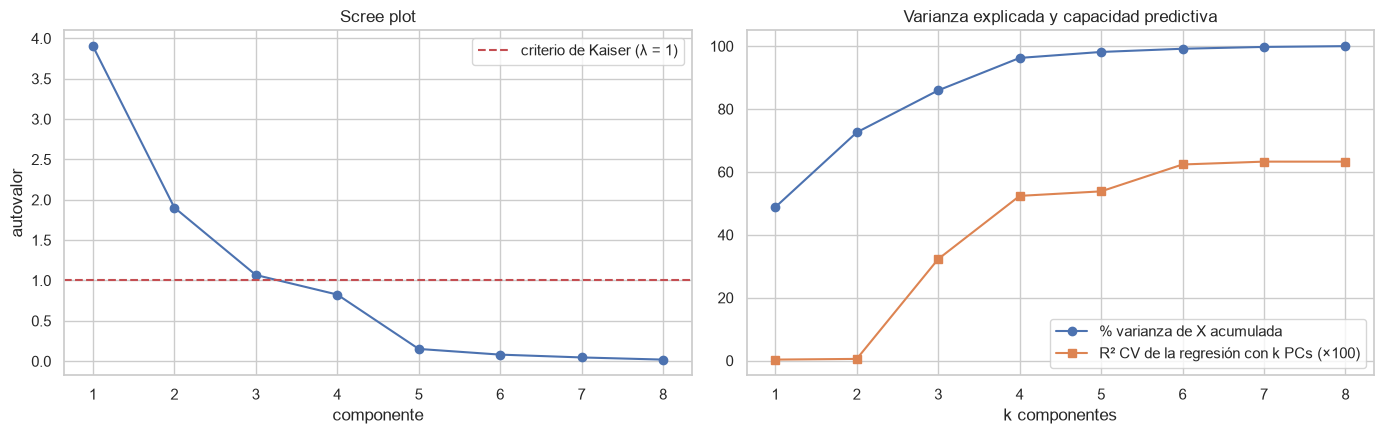

,1,2,3,4,5,6,7,8
R² CV,0.003,0.006,0.323,0.524,0.538,0.624,0.633,0.633


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
k_ = np.arange(1, 9)
axes[0].plot(k_, autovalores, "o-")
axes[0].axhline(1, color="r", ls="--", label="criterio de Kaiser (λ = 1)")
axes[0].set(xlabel="componente", ylabel="autovalor", title="Scree plot")
axes[0].legend()

r2_k = [cross_val_score(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                      PCA(n_components=k), LinearRegression()),
                        X_num_train, y_train_raw, cv=cv5, scoring="r2").mean() for k in k_]
axes[1].plot(k_, 100 * pca_full.explained_variance_ratio_.cumsum(), "o-", label="% varianza de X acumulada")
axes[1].plot(k_, 100 * np.array(r2_k), "s-", label="R² CV de la regresión con k PCs (×100)")
axes[1].set(xlabel="k componentes", title="Varianza explicada y capacidad predictiva")
axes[1].legend()
plt.tight_layout()
plt.show()
pd.Series(r2_k, index=k_, name="R² CV").round(3).to_frame().T

Hay **3 autovalores mayores que 1** (criterio de Kaiser) y un cuarto de ≈ 0.83, cerca del umbral.
Después hay un **codo muy marcado**: λ₅ ≈ 0.15. Con 4 componentes se conserva **≈ 96 % de la
varianza** de las 8 variables. Las 4 restantes casi no tienen varianza: son las combinaciones
redundantes del bloque colineal.

La curva de la derecha muestra algo importante: **varianza de $X$ no es lo mismo que capacidad de
predecir $y$**. Con 2 componentes (73 % de la varianza) el $R^2$ es prácticamente 0, y salta al
añadir la PC3 y la PC4. PCA no mira $y$: ordena las direcciones por cuánto varían, no por cuánto
predicen. Se conservan **k = 4** componentes, por el codo y por superar el 95 % de la varianza.

In [49]:
# Cargas de las componentes de baja varianza
pd.DataFrame(pca_full.components_[4:].T, index=num_features, columns=["PC5", "PC6", "PC7", "PC8"]).round(2)

,PC5,PC6,PC7,PC8
longitude,-0.09,0.49,-0.49,0.07
latitude,-0.04,0.47,-0.51,0.06
housing_median_age,-0.03,0.09,-0.04,-0.00
total_rooms,-0.30,0.56,0.57,0.13
total_bedrooms,-0.40,-0.22,-0.25,-0.69
population,0.85,0.11,-0.04,-0.15
households,-0.14,-0.39,-0.27,0.70
median_income,0.05,-0.06,-0.17,-0.03


El caso de la PC6 es llamativo: con solo **1 % de la varianza** de $X$, sube el $R^2$ de 0.54 a
0.62. Según sus cargas, la PC6 combina la otra diagonal geográfica (latitud + longitud,
perpendicular a la PC2) con un contraste `total_rooms` − `households` (más habitaciones para los
mismos hogares). PC5 y PC8 son contrastes dentro del bloque de tamaño (la PC5 opone
`population` a `total_bedrooms` y `total_rooms`; la PC8, `households` a `total_bedrooms`), y la
PC7 opone `total_rooms` a la ubicación. Son versiones lineales de
las razones del punto 13 y de una dirección de ubicación que la PC2 no recoge, es decir,
información que el modelo reducido deja por fuera. Se retoma más abajo.

#### Cargas: ¿qué resume cada componente?

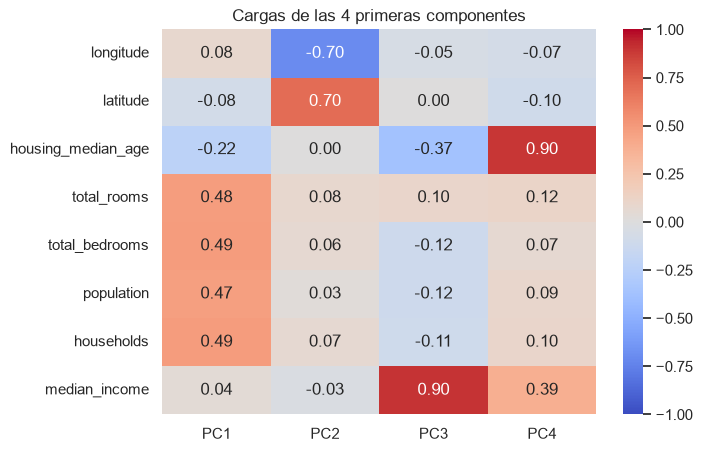

In [50]:
k = 4
nombres_pc = [f"PC{i}" for i in range(1, k + 1)]
cargas = pd.DataFrame(pca_full.components_[:k].T, index=num_features, columns=nombres_pc)

plt.figure(figsize=(7, 5))
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Cargas de las 4 primeras componentes")
plt.show()

El signo global de cada componente es arbitrario. Lo que importa son los pesos relativos:

| Componente | Cargas dominantes | Interpretación | Relación con los puntos 9 y 10 |
|---|---|---|---|
| **PC1** (≈ 49 %) | `total_rooms`, `total_bedrooms`, `population`, `households` ≈ 0.48 cada una | **Tamaño del distrito** | Es el bloque rojo de $\rho \approx 0.9$ de la matriz de correlación. Las 4 variables miden lo mismo y PCA las funde en una sola. |
| **PC2** (≈ 24 %) | `latitude` y `longitude` ≈ ±0.70 con signos opuestos | **Posición noroeste-sudeste** | Es el $\rho \approx -0.92$ entre latitud y longitud (la "diagonal" de California). |
| **PC3** (≈ 13 %) | `median_income` ≈ 0.90, `housing_median_age` ≈ −0.37 | **Nivel socioeconómico** | La única variable con correlación fuerte con el precio. En el pairplot es la relación más clara. |
| **PC4** (≈ 10 %) | `housing_median_age` ≈ 0.90, `median_income` ≈ 0.39 | **Antigüedad de las viviendas** | `housing_median_age` solo tiene correlaciones moderadas con el resto (la mayor, ≈ −0.36 con `total_rooms`), así que queda casi sola en su componente. |

Esto explica la curva de $R^2$: PC1 (tamaño) y PC2 (diagonal) casi no se relacionan **linealmente**
con el precio. La PC3 contiene el ingreso, el verdadero predictor. Las componentes de mayor varianza
no son las más predictivas.

#### ¿Aportan las variables del punto 13 información que las componentes no capturan?

In [51]:
# Razones calculadas sobre los datos imputados. Se usa el logaritmo: las razones tienen colas
# enormes (p. ej. 1 000 personas por hogar) que dominarían una regresión lineal.
num_imp = pd.DataFrame(pre_std[0].transform(X_num_train), columns=num_features, index=X_num_train.index)
razones = pd.DataFrame({
    "rooms_per_household": num_imp["total_rooms"] / num_imp["households"],
    "bedrooms_per_room": num_imp["total_bedrooms"] / num_imp["total_rooms"],
    "population_per_household": num_imp["population"] / num_imp["households"],
}).apply(np.log)

scores_pc = pd.DataFrame(pca_full.transform(Z)[:, :k], columns=nombres_pc, index=X_num_train.index)

pd.DataFrame({
    "R² explicado por las 4 PCs": [LinearRegression().fit(scores_pc, razones[c]).score(scores_pc, razones[c])
                                   for c in razones],
    "corr. con median_house_value": [np.corrcoef(razones[c], y_train_raw)[0, 1] for c in razones],
}, index=razones.columns).round(3)

,R² explicado por las 4 PCs,corr. con median_house_value
rooms_per_household,0.378,0.240
bedrooms_per_room,0.514,-0.322
population_per_household,0.028,-0.256


In [52]:
from sklearn.preprocessing import FunctionTransformer

def log_razones(d):
    d = pd.DataFrame(d, columns=["total_rooms", "total_bedrooms", "population", "households"])
    return np.log(np.column_stack([d["total_rooms"] / d["households"],
                                   d["total_bedrooms"] / d["total_rooms"],
                                   d["population"] / d["households"]]))

pca_mas_razones = Pipeline([
    ("prep", ColumnTransformer([
        ("pca", make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), PCA(n_components=k)), num_features),
        ("razones", make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(log_razones), StandardScaler()),
         ["total_rooms", "total_bedrooms", "population", "households"]),
    ])),
    ("modelo", LinearRegression()),
])
r2_pca_raz = cross_val_score(pca_mas_razones, X_num_train, y_train_raw, cv=cv5, scoring="r2").mean()
print(f"R² CV  4 PCs:                {r2_k[k - 1]:.4f}")
print(f"R² CV  4 PCs + 3 razones:    {r2_pca_raz:.4f}")

R² CV  4 PCs:                0.5239
R² CV  4 PCs + 3 razones:    0.6055


**Sí aportan.** Una componente principal es una **combinación lineal** de las variables originales,
y una razón como $\text{total\_rooms}/\text{households}$ es una relación **no lineal** (un cociente).
Las 4 PCs explican solo una parte de la varianza de cada razón (ver la tabla). PC1 dice *cuán grande*
es el distrito, no *cómo son* sus viviendas. Al añadir las 3 razones al modelo reducido el $R^2$ de
validación sube de 0.52 a 0.61, así que contienen información predictiva que PCA no captura.

#### Modelo reducido y comparación con la regresión completa

In [53]:
pipe_pca = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler()),
    ("pca", PCA(n_components=k)),
    ("modelo", LinearRegression()),
])
cv_pca = cross_validate(pipe_pca, X_num_train, y_train_raw, cv=cv5,
                        scoring=("r2", "neg_root_mean_squared_error"))
pipe_pca.fit(X_num_train, y_train_raw)

comparacion_23 = pd.DataFrame({
    "variables": [len(cols), k],
    "R² entrenamiento": [lin_reg.score(X_train, y_train), pipe_pca.score(X_num_train, y_train_raw)],
    "R² CV": [cv_lin["test_r2"].mean(), cv_pca["test_r2"].mean()],
    "RMSE CV": [-cv_lin["test_neg_root_mean_squared_error"].mean(),
                -cv_pca["test_neg_root_mean_squared_error"].mean()],
}, index=["Regresión lineal (punto 17)", f"PCA ({k} componentes)"])
comparacion_23.round(4)

,variables,R² entrenamiento,R² CV,RMSE CV
Regresión lineal (punto 17),13,0.6438,0.6417,69240.6917
PCA (4 componentes),4,0.5242,0.5239,79824.3227


In [54]:
print(f"R² que se pierde: {comparacion_23['R² CV'].iloc[0] - comparacion_23['R² CV'].iloc[1]:.3f}")

# ¿Cuánto se debe a reducir dimensiones y cuánto a no usar ocean_proximity?
r2_8num = cross_val_score(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LinearRegression()),
                          X_num_train, y_train_raw, cv=cv5, scoring="r2").mean()
print(f"R² CV regresión con las 8 numéricas (sin ocean_proximity): {r2_8num:.4f}")

R² que se pierde: 0.118


R² CV regresión con las 8 numéricas (sin ocean_proximity): 0.6327


Con **4 variables en lugar de 13** el modelo reducido pierde ≈ 0.12 de $R^2$ en validación (de
≈ 0.64 a ≈ 0.52) y el RMSE sube unos 10 000 USD. La pérdida tiene dos fuentes:

1. **No usar `ocean_proximity`.** El enunciado pide las variables *numéricas*, y la regresión con
   las 8 numéricas ya baja a ≈ 0.63, así que esta parte es pequeña.
2. **Descartar PC5-PC8.** Tienen solo ≈ 4 % de la varianza de $X$, pero contienen contrastes
   dentro del bloque colineal y la diagonal geográfica de la PC6, que sí predicen el precio. Por eso las razones del punto 13 recuperan parte de lo perdido.

#### Test de permutaciones: ¿el modelo reducido captura algo real?

Hipótesis nula $H_0$: no hay relación entre las componentes y el precio. Si fuera cierta, barajar
$y$ no cambiaría el $R^2$ de validación. Se baraja $y$ 200 veces, se recalcula el $R^2$ de CV en cada
caso y se compara con el $R^2$ real. El p-valor es
$p = \frac{1 + \#\{R^2_{\text{perm}} \geq R^2_{\text{real}}\}}{1 + 200}$.

R² real (CV) = 0.5239
R² con y permutado: media = -0.00065, máximo = 0.00035
p-valor = 0.0050  (el mínimo posible con 200 permutaciones es 0.0050)


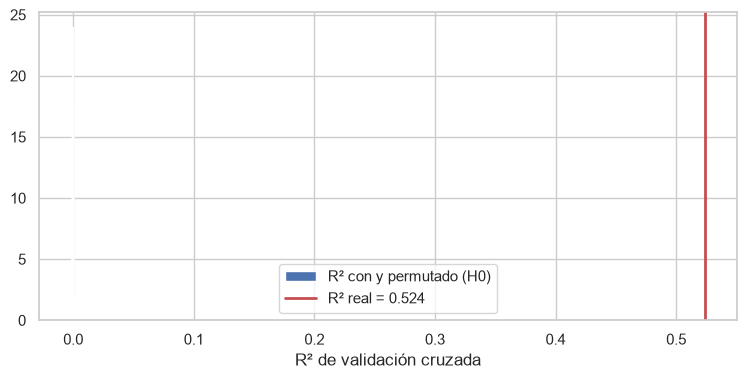

In [55]:
r2_real, r2_perm, p_valor = permutation_test_score(
    pipe_pca, X_num_train, y_train_raw, cv=cv5, scoring="r2",
    n_permutations=200, random_state=SEED, n_jobs=-1)

print(f"R² real (CV) = {r2_real:.4f}")
print(f"R² con y permutado: media = {r2_perm.mean():.5f}, máximo = {r2_perm.max():.5f}")
print(f"p-valor = {p_valor:.4f}  (el mínimo posible con 200 permutaciones es {1/201:.4f})")

plt.figure(figsize=(9, 4))
plt.hist(r2_perm, bins=30, label="R² con y permutado (H0)")
plt.axvline(r2_real, color="r", lw=2, label=f"R² real = {r2_real:.3f}")
plt.xlabel("R² de validación cruzada")
plt.legend()
plt.show()

Con $y$ permutado el $R^2$ queda en ≈ 0 en las 200 réplicas (máximo ≈ 0.0004), lo esperado sin
relación: el modelo no supera a la media, mientras que el modelo real llega a ≈ 0.52. **Ninguna permutación se acerca**, así que
$p = 1/201 \approx 0.005$, el mínimo alcanzable. Se rechaza $H_0$: el modelo reducido captura una
relación real entre las componentes y el precio, no ruido ni un artefacto del ajuste. Con más
permutaciones el p-valor bajaría todavía más.

#### Comparación de coeficientes

Coeficientes del modelo reducido (USD por 1 desviación estándar de la componente):
PC1     3558.0
PC2    -4056.0
PC3    63054.0
PC4    57070.0 



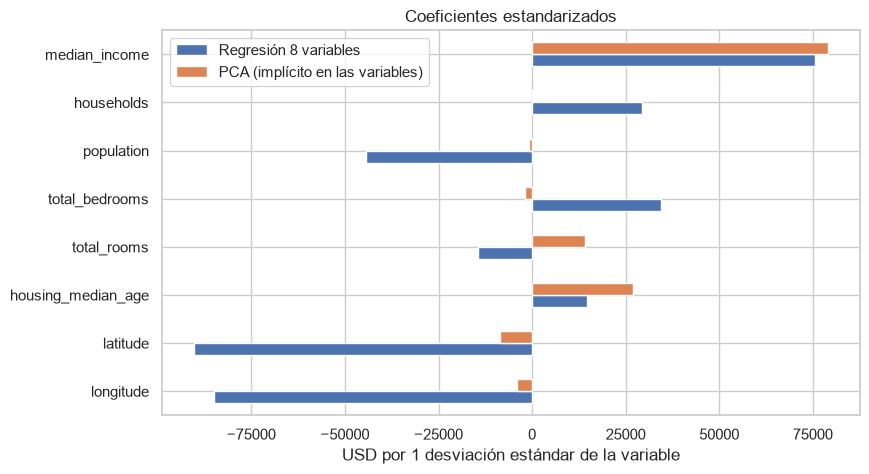

,Regresión 8 variables,PCA (implícito en las variables)
longitude,-84947.0,-4019.0
latitude,-90342.0,-8496.0
housing_median_age,14795.0,26838.0
total_rooms,-14426.0,14155.0
total_bedrooms,34355.0,-2010.0
population,-44262.0,-793.0
households,29333.0,372.0
median_income,75693.0,79045.0


In [56]:
coef_pc = pd.Series(pipe_pca["modelo"].coef_, index=nombres_pc)
print("Coeficientes del modelo reducido (USD por 1 desviación estándar de la componente):")
print(coef_pc.round(0).to_string(), "\n")

# Regresión lineal en la MISMA escala (estandarizada) para comparar con justicia
lin_std = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LinearRegression()).fit(X_num_train, y_train_raw)

# El modelo PCA también es lineal en las variables originales: beta_var = W beta_pc
beta_implicito = pd.Series(pca_full.components_[:k].T @ coef_pc.values, index=num_features)

tabla_coef = pd.DataFrame({"Regresión 8 variables": lin_std[-1].coef_,
                           "PCA (implícito en las variables)": beta_implicito},
                          index=num_features)
tabla_coef.plot.barh(figsize=(9, 5))
plt.xlabel("USD por 1 desviación estándar de la variable")
plt.title("Coeficientes estandarizados")
plt.show()
tabla_coef.round(0)

- **Regresión completa:** los coeficientes del bloque colineal son grandes y de **signos opuestos**
  (unas variables de tamaño positivas y otras negativas). Se cancelan entre sí y no se pueden leer
  como "efecto de aumentar las habitaciones". Con colinealidad tan fuerte, la varianza de estos coeficientes se infla (son poco estables). A
  eso se suman las dummies con su colinealidad exacta (punto 19).
- **Modelo reducido:** 4 coeficientes sobre componentes **ortogonales** (sin colinealidad), así
  que cada uno es estable y se lee por separado. Por ejemplo, +1 desviación de la PC3
  ("nivel socioeconómico") sube el precio en ≈ 63 000 USD, sin depender de las demás.
  Proyectado sobre las variables originales, el modelo PCA concentra el peso en `median_income`
  y `housing_median_age` (PC3 y PC4). A la ubicación y al bloque de tamaño les asigna pesos
  **menores** (el mayor, `total_rooms`, ≈ 14 000), porque PC1 y PC2 casi no predicen. Ya no hay coeficientes de decenas de miles que se
  cancelan entre sí.

**¿Cuál es más fácil de interpretar?** El modelo reducido, porque tiene pocos coeficientes, estables
y con nombre ("tamaño", "ubicación", "ingreso", "antigüedad"). El precio es que cada componente es
una **mezcla** de variables y hay que explicar las cargas. Además, el modelo predice peor.

# 4.0 Regularización: L2 vs L1

**24.** Responde con evidencia la pregunta del punto 21, *"¿Puede ser ajustado a otro modelo?"*, extendiendo la regresión lineal del punto 17 en dos pasos.

- Aumenta su complejidad, por ejemplo con términos polinomiales, hasta que sobreajuste. Muéstralo comparando su error con el de la regresión original.
- Controla el sobreajuste con Ridge (L2) y con Lasso (L1). Analiza cómo cambia el paso de gradiente descendente con el término L2.
- Grafica cómo evolucionan los coeficientes y el error al variar la intensidad de la regularización y explica las diferencias entre L1 y L2.
- Observa qué hace cada método con las variables colineales que identificaste en el punto 23.
- Organiza todo en un `Pipeline`, retomando lo planteado en el punto 22. Selecciona los hiperparámetros sin tocar el conjunto de test.

Todo se hace con `df_train` y validación cruzada (`cv5`). El test sigue aislado.

#### Paso 1. Más complejidad: términos polinomiales hasta sobreajustar

`PolynomialFeatures(d)` añade todos los productos de las 13 variables hasta grado $d$: 104 columnas
con $d = 2$ y 559 con $d = 3$. El modelo sigue siendo **lineal en los parámetros**, así que se ajusta
con mínimos cuadrados, pero ahora puede representar curvaturas e interacciones (por ejemplo,
latitud × longitud).

In [57]:
def pipe_polinomial(grado, modelo):
    return Pipeline([
        ("prep", preprocesador(StandardScaler())),
        ("poly", PolynomialFeatures(degree=grado, include_bias=False)),
        ("escalar", StandardScaler()),
        ("modelo", modelo),
    ])

filas, folds = [], {}
for g in (1, 2, 3):
    t0 = time.time()
    r = cross_validate(pipe_polinomial(g, LinearRegression()), X_train_raw, y_train_raw, cv=cv5,
                       scoring="neg_root_mean_squared_error", return_train_score=True)
    n_feat = pipe_polinomial(g, LinearRegression())[:2].fit(X_train_raw).transform(X_train_raw[:1]).shape[1]
    filas.append({"grado": g, "n_features": n_feat,
                  "RMSE entrenamiento": -r["train_score"].mean(),
                  "RMSE validación (CV)": -r["test_score"].mean(),
                  "tiempo [s]": time.time() - t0})
    folds[g] = -r["test_score"]

sobreajuste = pd.DataFrame(filas).set_index("grado")
display(sobreajuste.round(1))
display(pd.DataFrame(folds, index=[f"pliegue {i}" for i in range(1, 6)]).round(0).rename(columns=lambda g: f"grado {g}"))

,n_features,RMSE entrenamiento,RMSE validación (CV),tiempo [s]
grado,,,,
1,13,69030.4,69241.4,0.3
2,104,62095.2,74898.6,0.9
3,559,54367.7,204983.6,5.8


,grado 1,grado 2,grado 3
pliegue 1,67590.0,61812.0,56948.0
pliegue 2,68888.0,62611.0,65039.0
pliegue 3,71107.0,123170.0,724842.0
pliegue 4,70089.0,63219.0,117940.0
pliegue 5,68532.0,63680.0,60149.0


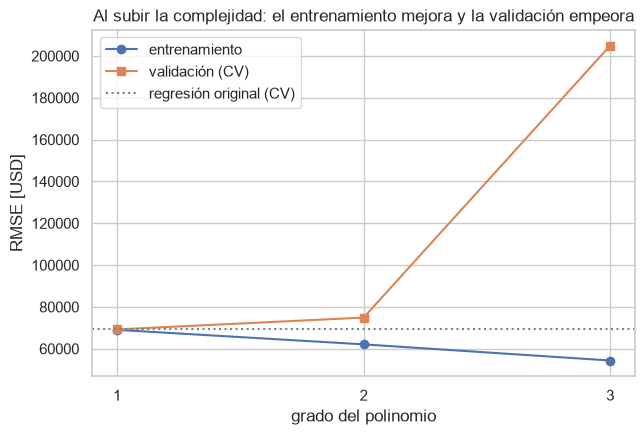

In [58]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sobreajuste.index, sobreajuste["RMSE entrenamiento"], "o-", label="entrenamiento")
ax.plot(sobreajuste.index, sobreajuste["RMSE validación (CV)"], "s-", label="validación (CV)")
ax.axhline(sobreajuste.loc[1, "RMSE validación (CV)"], color="gray", ls=":", label="regresión original (CV)")
ax.set(xlabel="grado del polinomio", ylabel="RMSE [USD]", xticks=[1, 2, 3],
       title="Al subir la complejidad: el entrenamiento mejora y la validación empeora")
ax.legend()
plt.show()

In [59]:
# ¿Por qué un pliegue explota? Se miran los peores errores del grado 3
pred_g3 = cross_val_predict(pipe_polinomial(3, LinearRegression()), X_train_raw, y_train_raw, cv=cv5)
err = pd.Series(np.abs(y_train_raw.to_numpy() - pred_g3), index=X_train_raw.index)
peores = df_train.loc[err.nlargest(5).index, ["total_rooms", "population", "households", "median_income", target]].copy()
peores["predicción grado 3"] = pred_g3[X_train_raw.index.get_indexer(peores.index)]
print("Percentil 99.9 de population en train:", df_train["population"].quantile(0.999))
peores.round(0)

Percentil 99.9 de population en train: 9903.807000000088


,total_rooms,population,households,median_income,median_house_value,predicción grado 3
15360,25135.0,35682.0,4769.0,3.0,134400.0,-41288597.0
18346,11709.0,7604.0,3589.0,2.0,375000.0,6240188.0
19006,19.0,7460.0,6.0,10.0,137500.0,2897283.0
17413,17738.0,12427.0,2826.0,3.0,28300.0,1221557.0
9172,538.0,8733.0,105.0,4.0,154600.0,-870955.0


**El modelo polinomial sobreajusta.** Al subir de grado, el RMSE de **entrenamiento baja** porque el
modelo tiene más libertad. El de **validación sube** por encima del de la regresión original. La
brecha entre ambas curvas es la firma del sobreajuste (**alta varianza**). Con grado 3 el RMSE
de validación promedio llega a ≈ 205 000 USD, tres veces el de la recta.

La tabla por pliegues muestra **cómo** sobreajusta. En 3 de los 5 pliegues el grado 3 valida
*mejor* que la recta: hay estructura no lineal real. En los otros dos, en cambio, el error se
dispara (hasta ≈ 725 000 USD en el pliegue 3).
Los peores errores están en **distritos extremos** (por ejemplo, 35 682 habitantes, o 7 460
habitantes en solo 6 hogares):
fuera del rango donde hay muchos datos, el polinomio de grado 3 **extrapola** a predicciones
absurdas (millones de dólares o valores negativos). Ese es el
comportamiento que la regularización debe controlar.

#### Paso 2. El término L2 en el gradiente descendente

Ridge añade a la función de coste del Laboratorio 4 una penalización sobre los coeficientes (el
intercepto $\theta_0$ no se penaliza):

$$
J(\theta) = \frac{1}{2m}\sum_{i=1}^m \left(h_\theta(x^{(i)}) - y^{(i)}\right)^2
          + \frac{\lambda}{2m}\sum_{j=1}^p \theta_j^2
$$

Su gradiente tiene un término extra, proporcional al propio coeficiente:

$$
\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_i \left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}
+ \frac{\lambda}{m}\theta_j
$$

y la regla de actualización con tasa $\eta$ queda

$$
\theta_j \leftarrow \underbrace{\left(1 - \frac{\eta\lambda}{m}\right)\theta_j}_{\text{encogimiento}}
\;-\; \eta\,\frac{1}{m}\sum_i \left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}
$$

En cada paso, **antes** del paso de gradiente usual, cada coeficiente se multiplica por un factor
$1 - \eta\lambda/m < 1$: se encoge hacia 0 (*weight decay*). Hay dos consecuencias:

1. El mínimo ya no está donde el error es mínimo, sino donde el gradiente del error se **equilibra**
   con la fuerza que tira de $\theta$ hacia 0. El resultado son coeficientes más pequeños.
2. La matriz que gobierna la convergencia pasa de $\frac{1}{m}X^TX$ a $\frac{1}{m}X^TX + \frac{\lambda}{m}I$:
   todos sus autovalores **suben en $\lambda/m$**. Con variables colineales, $X^TX$ tiene autovalores
   casi nulos, y en esas direcciones el gradiente descendente sin regularizar avanza muy lento (o no
   tiene un mínimo único). El término L2 vuelve el problema **bien condicionado** y el descenso
   converge mucho más rápido.

Multiplicando $J$ por $2m$ se obtiene $\|y - X\theta\|^2 + \lambda\|\theta\|^2$, que es exactamente
la función que minimiza `Ridge(alpha=λ)` de sklearn. Se comprueba con una implementación propia:

autovalores de X^T X / m: mínimo = -3.78e-16, máximo = 3.93


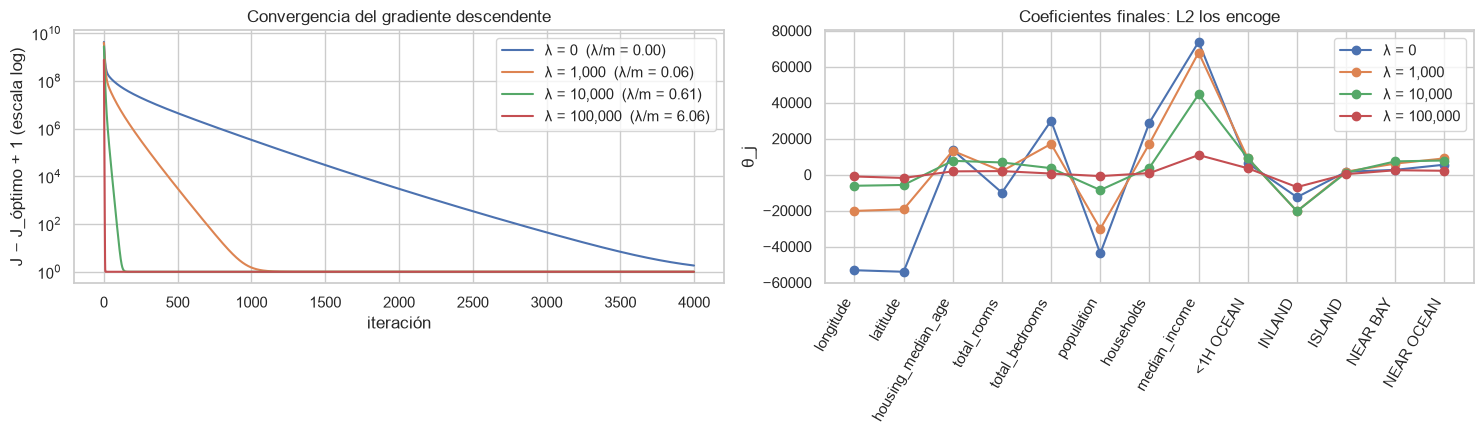

,λ,λ/m,‖θ‖ (GD),J_GD − J_óptimo,máx |θ_GD − θ_Ridge|,número de condición
0,0,0.000,123927.235,0.826,12.013,inf
1,1000,0.061,87630.043,0.000,0.000,65.831
2,10000,0.606,53654.883,0.000,0.000,7.483
3,100000,6.056,14242.032,0.000,0.000,1.648


In [60]:
def gd_ridge(X, y, lam, eta=0.1, n_iter=4000):
    # Gradiente descendente con penalización L2. X debe estar centrada: así el intercepto óptimo es
    # mean(y) (no se penaliza) y basta con actualizar los coeficientes.
    m, p = X.shape
    b = y.mean()
    theta = np.zeros(p)
    coste = np.empty(n_iter)
    for it in range(n_iter):
        r = X @ theta + b - y
        coste[it] = (r @ r + lam * theta @ theta) / (2 * m)
        grad = X.T @ r / m
        theta = (1 - eta * lam / m) * theta - eta * grad     # encogimiento + paso usual
    return b, theta, coste

# Las 13 variables de la regresión original, estandarizadas y centradas (también las dummies)
prep_gd = make_pipeline(preprocesador(StandardScaler()), StandardScaler())
X_gd = prep_gd.fit_transform(X_train_raw)
y_gd = y_train_raw.to_numpy()
m = len(y_gd)

ev = np.linalg.eigvalsh(X_gd.T @ X_gd / m)
print(f"autovalores de X^T X / m: mínimo = {ev.min():.2e}, máximo = {ev.max():.2f}")

lambdas = [0, 1_000, 10_000, 100_000]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
filas = []
for lam in lambdas:
    b, th, coste = gd_ridge(X_gd, y_gd, lam)
    ref_ridge = Ridge(alpha=lam if lam > 0 else 1e-8).fit(X_gd, y_gd)
    j_opt = (np.sum((y_gd - ref_ridge.predict(X_gd)) ** 2) + lam * ref_ridge.coef_ @ ref_ridge.coef_) / (2 * m)
    axes[0].semilogy(coste - j_opt + 1, label=f"λ = {lam:,}  (λ/m = {lam/m:.2f})")
    filas.append({"λ": lam, "λ/m": lam / m, "‖θ‖ (GD)": np.linalg.norm(th),
                  "J_GD − J_óptimo": coste[-1] - j_opt,
                  "máx |θ_GD − θ_Ridge|": np.abs(th - ref_ridge.coef_).max(),
                  "número de condición": (ev.max() + lam / m) / (ev.min() + lam / m) if lam else np.inf})
    axes[1].plot(range(len(th)), th, "o-", label=f"λ = {lam:,}")
axes[0].set(xlabel="iteración", ylabel="J − J_óptimo + 1 (escala log)", title="Convergencia del gradiente descendente")
axes[0].legend()
axes[1].set_xticks(range(len(cols)))
axes[1].set_xticklabels(cols, rotation=60, ha="right")
axes[1].set(ylabel="θ_j", title="Coeficientes finales: L2 los encoge")
axes[1].legend()
plt.tight_layout()
plt.show()
pd.DataFrame(filas).round(3)

- Con **λ = 0**, el autovalor mínimo de $X^TX/m$ es 0 (las 5 dummies son exactamente
  colineales) y el número de condición es infinito. La curva de coste baja lentamente y, tras 4 000
  iteraciones, todavía no alcanza el óptimo. El problema está mal condicionado.
- Al aumentar **λ**, los autovalores suben en $\lambda/m$, el número de condición cae y el
  gradiente descendente **converge mucho más rápido** (en la figura, del orden de 1 000 iteraciones con λ = 1 000,
  ≈ 150 con λ = 10 000 y casi de inmediato con λ = 100 000) a la misma solución que `Ridge` de
  sklearn (diferencia de coeficientes y de coste ≈ 0). Pasa de un número de condición infinito a 66
  con λ = 1 000 y a 1.6 con λ = 100 000.
- La norma $\|\theta\|$ **disminuye** con λ: es el encogimiento. Los coeficientes grandes y de signos
  opuestos (bloque de tamaño, latitud y longitud) se reducen con fuerza. En la figura, `latitude`
  pasa de ≈ −54 000 con λ = 0 a ≈ −6 000 con λ = 10 000.

**Nota sobre L1.** La penalización $\lambda\sum_j|\theta_j|$ no es derivable en 0, así que no hay un
paso de gradiente simple. El paso equivalente (*soft-thresholding*) resta una cantidad **fija**
$\eta\lambda/m$ al valor absoluto de cada coeficiente y lo deja en **0 exacto** si no le alcanza.
L2, en cambio, lo multiplica por un factor y nunca lo anula. Esa es la raíz de la diferencia L1/L2
que se ve en el paso siguiente.

#### Paso 3. Trayectorias de los coeficientes al variar la regularización

Para ver con claridad el comportamiento de cada variable se usan las 13 variables originales
estandarizadas (grado 1). Las de color son el bloque colineal identificado en el punto 23 (PC1).

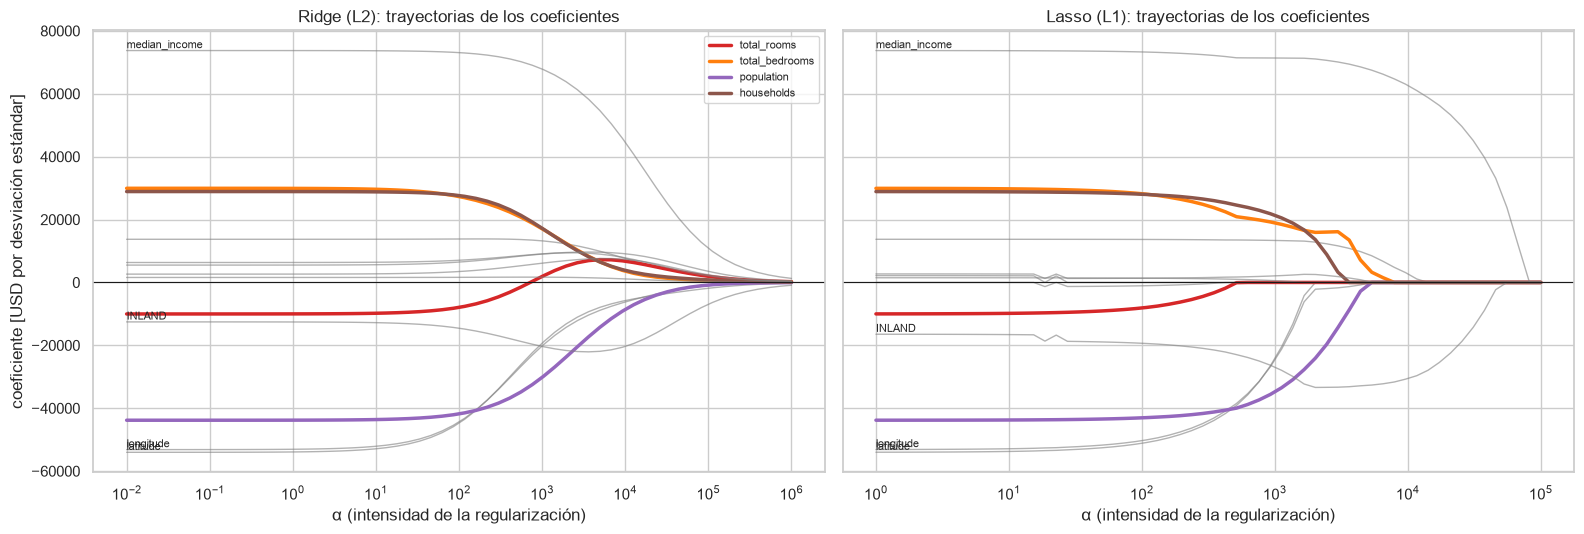

In [61]:
bloque = ["total_rooms", "total_bedrooms", "population", "households"]
destacadas = ["median_income", "INLAND", "latitude", "longitude"]
colores = dict(zip(bloque, ["tab:red", "tab:orange", "tab:purple", "tab:brown"]))

alphas_ridge = np.logspace(-2, 6, 60)
alphas_lasso = np.logspace(0, 5, 60)
coef_ridge = np.array([Ridge(alpha=a).fit(X_gd, y_gd).coef_ for a in alphas_ridge])
coef_lasso = np.array([Lasso(alpha=a, max_iter=50_000, precompute=True).fit(X_gd, y_gd).coef_ for a in alphas_lasso])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, A, C, nombre in ((axes[0], alphas_ridge, coef_ridge, "Ridge (L2)"),
                         (axes[1], alphas_lasso, coef_lasso, "Lasso (L1)")):
    for j, c in enumerate(cols):
        if c in bloque:
            ax.semilogx(A, C[:, j], color=colores[c], lw=2.5, label=c)
        else:
            ax.semilogx(A, C[:, j], color="gray", lw=1, alpha=0.6)
            if c in destacadas:
                ax.annotate(c, (A[0], C[0, j]), fontsize=8, ha="left", va="bottom")
    ax.axhline(0, color="k", lw=0.8)
    ax.set(xlabel="α (intensidad de la regularización)", title=f"{nombre}: trayectorias de los coeficientes")
axes[0].set_ylabel("coeficiente [USD por desviación estándar]")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [62]:
# Último α en que cada variable sigue activa en Lasso: las que sobreviven más son las más importantes
ultimo_alpha = {c: (alphas_lasso[np.nonzero(coef_lasso[:, j])[0].max()] if np.any(coef_lasso[:, j]) else 0)
                for j, c in enumerate(cols)}
pd.Series(ultimo_alpha, name="último α con coeficiente ≠ 0").sort_values(ascending=False).round(0).to_frame()

,último α con coeficiente ≠ 0
median_income,67688.0
INLAND,45816.0
housing_median_age,11690.0
total_bedrooms,6510.0
NEAR OCEAN,5356.0
longitude,4406.0
population,4406.0
households,2982.0
latitude,1661.0
ISLAND,1366.0


**Diferencias L1 vs L2:**

- **Ridge (L2)** encoge **todos** los coeficientes de forma **suave y continua** hacia 0, pero
  ninguno llega a ser exactamente 0. Siempre se conservan las 13 variables.
- **Lasso (L1)** los encoge y además los **anula uno a uno**: es selección de variables automática.
  Las trayectorias son lineales a tramos en α (en el gráfico, con eje logarítmico, se ven
curvas) y tocan 0 en un α concreto. Las que sobreviven más son las
  más relevantes para predecir el precio.

**Qué hace cada método con el bloque colineal (`total_rooms`, `total_bedrooms`, `population`, `households`):**

- Sin regularizar (α pequeño) los cuatro tienen coeficientes grandes y de **signos opuestos** que se
  cancelan, como en el punto 23.
- **Ridge** los encoge **juntos** y reduce la distancia entre ellos: los cuatro siguen activos y
  la diferencia entre el mayor y el menor pasa de ≈ 74 000 a ≈ 15 000 USD con α = 10⁴, hasta que
  todos tienden a 0. Ridge penaliza más las direcciones de autovalor pequeño, que son justamente las
  *diferencias* entre variables colineales. Por eso las contradicciones se atenúan primero, en la
  misma línea en que PCA funde el bloque en la PC1.
- **Lasso** **elige** dentro del bloque: anula `total_rooms` casi de inmediato (α ≈ 500), luego
  `households`, y mantiene `population` y `total_bedrooms` hasta α ≈ 4 400 y ≈ 6 500. La elección entre
  variables casi idénticas es algo arbitraria (inestable ante pequeños cambios en los datos).

#### Paso 4. Todo en un `Pipeline` y selección de hiperparámetros sin tocar el test

Se buscan conjuntamente el **grado** del polinomio y la **intensidad α** con `GridSearchCV` sobre
`df_train` (validación cruzada de 5 pliegues). El preprocesamiento va dentro del pipeline, así que
se reajusta en cada pliegue y el test no interviene en ninguna decisión.

Las escalas de α no son comparables entre los dos métodos: sklearn minimiza
$\|y-X\theta\|^2 + \alpha\|\theta\|_2^2$ en Ridge y $\frac{1}{2n}\|y-X\theta\|^2 + \alpha\|\theta\|_1$ en
Lasso. En Lasso se usa `precompute=True` (matriz de Gram precalculada), que acelera mucho el
descenso por coordenadas con cientos de columnas.

In [63]:
grid_ridge = GridSearchCV(
    pipe_polinomial(1, Ridge()),
    {"poly__degree": [1, 2, 3], "modelo__alpha": np.logspace(-1, 4, 11)},
    cv=cv5, scoring="neg_root_mean_squared_error", return_train_score=True, n_jobs=-1)

grid_lasso = GridSearchCV(
    pipe_polinomial(1, Lasso(max_iter=20_000, tol=1e-4, precompute=True)),
    {"poly__degree": [1, 2, 3], "modelo__alpha": np.logspace(0, 4, 9)},
    cv=cv5, scoring="neg_root_mean_squared_error", return_train_score=True, n_jobs=-1)

for nombre, g in (("Ridge", grid_ridge), ("Lasso", grid_lasso)):
    t0 = time.time()
    g.fit(X_train_raw, y_train_raw)
    print(f"{nombre}: mejor {g.best_params_}  RMSE CV = {-g.best_score_:,.0f}   ({time.time() - t0:.0f} s)")

Ridge: mejor {'modelo__alpha': np.float64(316.22776601683796), 'poly__degree': 3}  RMSE CV = 60,656   (11 s)


Lasso: mejor {'modelo__alpha': np.float64(1000.0), 'poly__degree': 3}  RMSE CV = 63,958   (17 s)


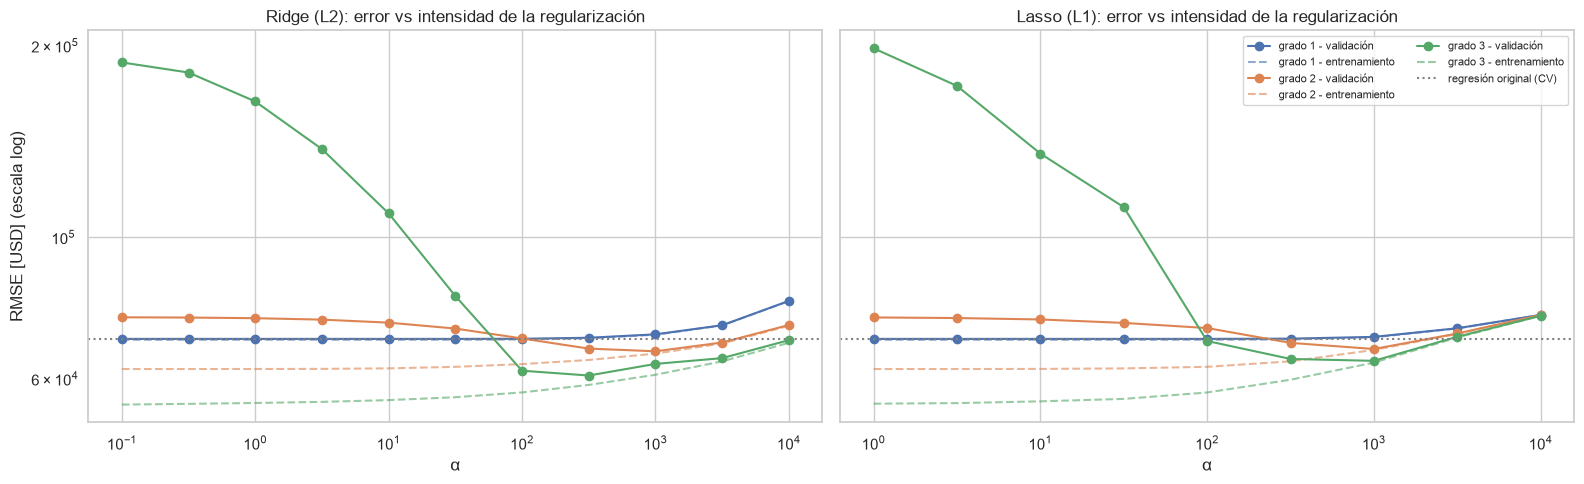

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, (nombre, g) in zip(axes, (("Ridge (L2)", grid_ridge), ("Lasso (L1)", grid_lasso))):
    res_g = pd.DataFrame(g.cv_results_)
    for grado, sub in res_g.groupby("param_poly__degree"):
        sub = sub.sort_values("param_modelo__alpha")
        a = sub["param_modelo__alpha"].astype(float)
        ln = ax.loglog(a, -sub["mean_test_score"], "o-", label=f"grado {grado} - validación")[0]
        ax.loglog(a, -sub["mean_train_score"], "--", color=ln.get_color(), alpha=0.6, label=f"grado {grado} - entrenamiento")
    ax.axhline(sobreajuste.loc[1, "RMSE validación (CV)"], color="gray", ls=":", label="regresión original (CV)")
    ax.set(xlabel="α", title=f"{nombre}: error vs intensidad de la regularización")
axes[0].set_ylabel("RMSE [USD] (escala log)")
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Las curvas de error muestran el **compromiso sesgo-varianza**:

- **α pequeño** (izquierda): casi sin regularización, el grado 3 se comporta como en el paso 1. El
  entrenamiento es bajo, pero la validación es muy alta por los pliegues que extrapolan (varianza).
- **α grande** (derecha): los coeficientes se encogen tanto que el modelo pierde flexibilidad y
  ambos errores suben juntos (sesgo).
- **α intermedio**: el error de validación tiene un **mínimo**, y para grado 3 queda **por debajo
  de la regresión original**. Con regularización, el polinomio conserva la estructura no lineal útil
  y se controla la extrapolación.

**Respuesta al punto 21 con evidencia:** sí se puede ajustar otro modelo mejor dentro de la familia
lineal. Un polinomio con Ridge o Lasso, con grado y α elegidos por validación cruzada, baja el RMSE
de validación respecto a la regresión original. Sin regularizar, ese mismo polinomio es peor que la
recta.

# 5.0 Comparación final

**25.** Evalúa en `housing_test`, con la misma partición y la misma métrica, cuatro modelos:

- la regresión lineal del punto 17,
- el modelo reducido del punto 23,
- el mejor Ridge del punto 24,
- el mejor Lasso del punto 24.

Después responde:

- Con bootstrap, determina si las diferencias de desempeño frente a la regresión del punto 17 son estadísticamente significativas.
- ¿Las variables que conserva Lasso se relacionan con las que destacó PCA? ¿Por qué?
- Vuelve a responder los puntos 18 a 20 a la luz de esta comparación. ¿Cambió tu conclusión sobre la regresión lineal original?
- ¿Cuánto desempeño se pierde a cambio de interpretabilidad? ¿Qué modelo presentarías a alguien que no es especialista, y por qué?

Es la **primera y única vez** que se usa el conjunto de test. Todos los modelos ya están ajustados
con `df_train` (los de `GridSearchCV` se reentrenan con todo el entrenamiento usando los mejores
hiperparámetros).

In [65]:
X_test_raw = df_test.drop(target, axis=1)
y_test = df_test[target].to_numpy()

predicciones = {
    "Regresión lineal (p17)": lin_reg.predict(housing_test[cols]),
    f"PCA {k} comp. (p23)": pipe_pca.predict(X_test_raw[num_features]),
    "Mejor Ridge (p24)": grid_ridge.best_estimator_.predict(X_test_raw),
    "Mejor Lasso (p24)": grid_lasso.best_estimator_.predict(X_test_raw),
}
n_param = {
    "Regresión lineal (p17)": len(cols) + 1,
    f"PCA {k} comp. (p23)": k + 1,
    "Mejor Ridge (p24)": grid_ridge.best_estimator_["modelo"].coef_.size + 1,
    "Mejor Lasso (p24)": int(np.sum(grid_lasso.best_estimator_["modelo"].coef_ != 0)) + 1,
}

resultados = pd.DataFrame({
    nombre: {"RMSE test": mean_squared_error(y_test, p) ** 0.5,
             "MAE test": mean_absolute_error(y_test, p),
             "R² test": r2_score(y_test, p),
             "parámetros no nulos": n_param[nombre],
             "máx |error|": np.abs(y_test - p).max()}
    for nombre, p in predicciones.items()}).T
resultados["RMSE CV (train)"] = [-cv_lin["test_neg_root_mean_squared_error"].mean(),
                                 -cv_pca["test_neg_root_mean_squared_error"].mean(),
                                 -grid_ridge.best_score_, -grid_lasso.best_score_]
resultados.round(3)

,RMSE test,MAE test,R² test,parámetros no nulos,máx |error|,RMSE CV (train)
Regresión lineal (p17),67346.880,49775.596,0.652,14.0,335891.688,69240.692
PCA 4 comp. (p23),78927.548,59478.467,0.522,5.0,380308.502,79824.323
Mejor Ridge (p24),58870.760,41317.919,0.734,560.0,717286.665,60655.857
Mejor Lasso (p24),62356.074,45051.879,0.702,74.0,331507.770,63957.739


#### Bootstrap: ¿son significativas las diferencias frente a la regresión del punto 17?

Las cuatro predicciones se hicieron sobre **los mismos** 4 128 distritos de test, así que se usa un
**bootstrap pareado**: en cada réplica se remuestrean (con reemplazo) los índices del test, se
calcula el RMSE de cada modelo **sobre la misma muestra** y se guarda la diferencia
$\Delta = \text{RMSE}_{\text{modelo}} - \text{RMSE}_{\text{p17}}$. Si el intervalo del 95 % de
$\Delta$ no contiene el 0, la diferencia es significativa.

,Δ RMSE observado,IC 95 % inferior,IC 95 % superior,p (bootstrap),¿significativa?
modelo,,,,,
PCA 4 comp. (p23),11580.6680,10414.9483,12701.0766,0.0,sí
Mejor Ridge (p24),-8476.1197,-10130.2755,-6137.4300,0.0,sí
Mejor Lasso (p24),-4990.8057,-5847.3255,-4122.7379,0.0,sí


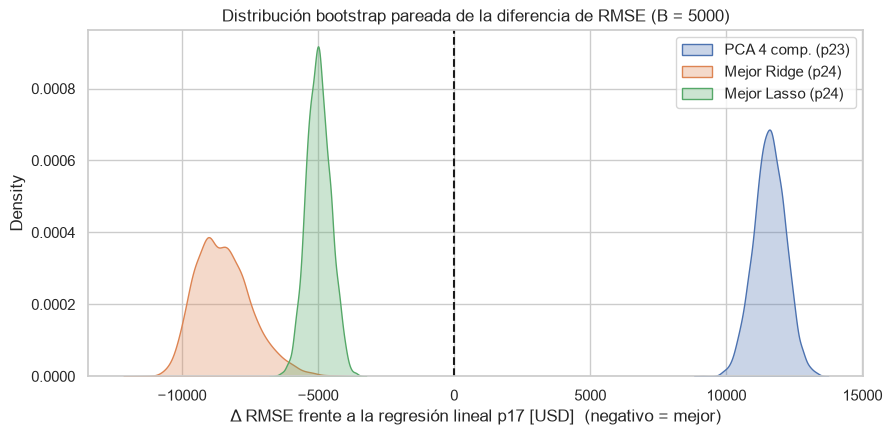

In [66]:
B = 5000
rng = np.random.default_rng(SEED)
idx = rng.integers(0, len(y_test), size=(B, len(y_test)))

rmse_boot = {nombre: np.sqrt(((y_test[idx] - p[idx]) ** 2).mean(axis=1)) for nombre, p in predicciones.items()}
ref = "Regresión lineal (p17)"

filas = []
for nombre in predicciones:
    if nombre == ref:
        continue
    delta = rmse_boot[nombre] - rmse_boot[ref]
    li, ls = np.percentile(delta, [2.5, 97.5])
    # p-valor bilateral aproximado: fracción de réplicas al otro lado del 0
    p_boot = min(1.0, 2 * min((delta <= 0).mean(), (delta >= 0).mean()))
    filas.append({"modelo": nombre,
                  "Δ RMSE observado": resultados.loc[nombre, "RMSE test"] - resultados.loc[ref, "RMSE test"],
                  "IC 95 % inferior": li, "IC 95 % superior": ls, "p (bootstrap)": p_boot,
                  "¿significativa?": "sí" if (li > 0 or ls < 0) else "no"})
tabla_boot = pd.DataFrame(filas).set_index("modelo")
display(tabla_boot.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
for nombre in predicciones:
    if nombre != ref:
        sns.kdeplot(rmse_boot[nombre] - rmse_boot[ref], ax=ax, fill=True, alpha=0.3, label=nombre)
ax.axvline(0, color="k", ls="--")
ax.set(xlabel="Δ RMSE frente a la regresión lineal p17 [USD]  (negativo = mejor)",
       title=f"Distribución bootstrap pareada de la diferencia de RMSE (B = {B})")
ax.legend()
plt.show()

#### ¿Las variables que conserva Lasso se relacionan con las que destacó PCA?

Lasso conserva 73 de 559 términos polinomiales


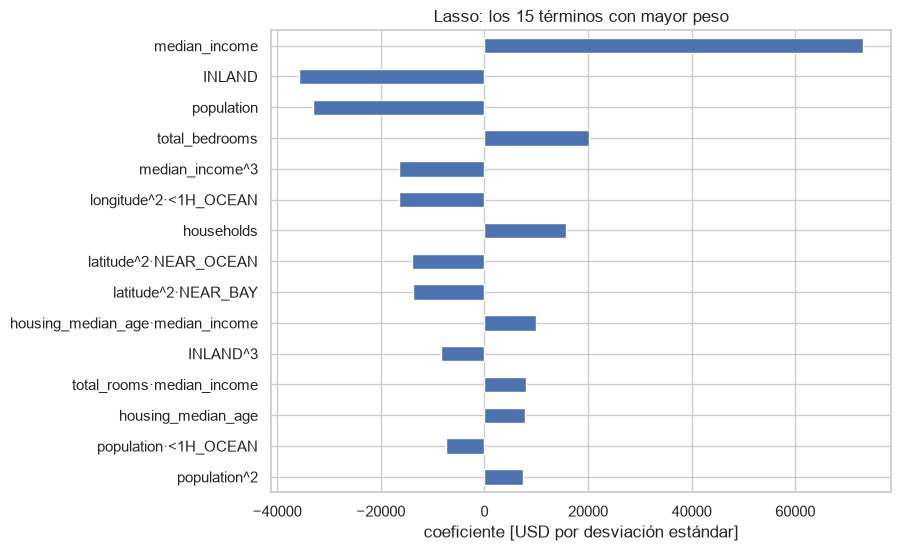

,coeficiente
median_income,73060.0
INLAND,-35727.0
population,-33088.0
total_bedrooms,20116.0
median_income^3,-16506.0
longitude^2·<1H_OCEAN,-16452.0
households,15703.0
latitude^2·NEAR_OCEAN,-13958.0
latitude^2·NEAR_BAY,-13875.0
housing_median_age·median_income,9934.0


In [67]:
mejor_lasso = grid_lasso.best_estimator_
nombres_poly = mejor_lasso[:-1].get_feature_names_out()
coef_l = pd.Series(mejor_lasso["modelo"].coef_, index=nombres_poly)
no_nulos = coef_l[coef_l != 0]
print(f"Lasso conserva {len(no_nulos)} de {len(coef_l)} términos polinomiales")

# Nombres legibles: 'num__median_income cat__ocean_proximity_INLAND' -> 'median_income·INLAND'
def legible(s):
    s = s.replace("num__", "").replace("cat__ocean_proximity_", "")
    for cat in ("<1H OCEAN", "NEAR BAY", "NEAR OCEAN"):      # categorías con espacio -> guion bajo
        s = s.replace(cat, cat.replace(" ", "_"))
    return s.replace(" ", "·")                              # PolynomialFeatures separa factores con espacio
top = no_nulos.reindex(no_nulos.abs().sort_values(ascending=False).index)[:15]
top.index = top.index.map(legible)
top.plot.barh(figsize=(8, 6)).invert_yaxis()
plt.xlabel("coeficiente [USD por desviación estándar]")
plt.title("Lasso: los 15 términos con mayor peso")
plt.show()
top.round(0).to_frame("coeficiente")

In [68]:
# ¿En cuántos términos activos aparece cada variable original y con cuánto peso total?
def variables_de(termino):
    return {f.split("^")[0] for f in legible(termino).split("·")}

originales = num_features + ["<1H_OCEAN", "INLAND", "ISLAND", "NEAR_BAY", "NEAR_OCEAN"]
presencia = pd.DataFrame({
    "términos activos": [sum(v in variables_de(t) for t in no_nulos.index) for v in originales],
    "peso total |coef|": [no_nulos[[v in variables_de(t) for t in no_nulos.index]].abs().sum() for v in originales],
}, index=originales).sort_values("peso total |coef|", ascending=False)
presencia.round(0)

,términos activos,peso total |coef|
median_income,22,135720.0
housing_median_age,21,69984.0
population,14,62257.0
INLAND,8,55280.0
<1H_OCEAN,15,55222.0
total_bedrooms,9,51862.0
longitude,12,41970.0
latitude,11,40470.0
NEAR_BAY,8,29510.0
households,6,24621.0


**Sí se relacionan, aunque por razones distintas.**

- El término dominante de Lasso es `median_income` (lineal y en interacciones). Es la variable que
  carga la **PC3**, la componente que hizo saltar el $R^2$ en el punto 23.
- La **ubicación** es el otro gran grupo. `INLAND` es el segundo término lineal más fuerte, y
  Lasso conserva potencias de latitud y longitud combinadas con las categorías de
  `ocean_proximity` (por ejemplo `longitude^2·<1H_OCEAN` o `latitude^2·NEAR_BAY`). Corresponde a la
  **PC2** de PCA más la información de `ocean_proximity`, que el modelo PCA no tenía. Así es como
  el polinomio aproxima el gradiente espacial no lineal del punto 11.
- `housing_median_age` es la segunda variable por peso total sumado, sobre todo a través de
  interacciones (por ejemplo, con `median_income`). Es la variable que domina la **PC4**, cuyo
  coeficiente en el modelo reducido era casi tan grande como el de la PC3.
- Del **bloque de tamaño** (PC1), Lasso no conserva la dirección "tamaño total", que no predice,
  sino **contrastes**. En los términos lineales, `population` entra con signo negativo y
  `total_bedrooms` y `households` con signo positivo, y `total_rooms` solo aparece en 3
  interacciones con el ingreso. Un contraste del tipo "más personas para los mismos hogares,
  menor precio" es la información de `population_per_household` (punto 13) y de las PCs de baja
  varianza que el modelo reducido descartó. PCA funde el bloque en una componente y Lasso conserva
  solo las diferencias útiles: ambos responden a la misma colinealidad.

La diferencia de fondo es que PCA elige direcciones por **varianza de $X$** (no supervisado) y Lasso
por **utilidad para predecir $y$** (supervisado). Coinciden en *qué grupos de variables* existen
(tamaño, ubicación, ingreso, antigüedad), pero no en su importancia. Para PCA el tamaño es lo
primero (49 % de la varianza) y no predice por sí solo, mientras que el ingreso, tercero en PCA, es
lo primero para Lasso.

#### Puntos 18-20 revisitados y conclusión

**18. ¿Qué se concluye del modelo original?** En test, la regresión lineal confirma lo que decía la
validación cruzada: $R^2 = 0.65$ y RMSE ≈ 67 300 USD en test, frente a 0.64 y 69 200 en CV. Los
valores coinciden, lo que indica que la estimación del punto 17 era honesta. La comparación muestra que su
problema era **sesgo, no varianza**. Los modelos polinomiales regularizados bajan el error en test
(Ridge: −8 500 USD de RMSE, $R^2 = 0.73$; Lasso: −5 000 USD, $R^2 = 0.70$) y el bootstrap indica que
esas mejoras son **estadísticamente significativas**: los IC del 95 % de Δ RMSE,
[−10 100, −6 100] y [−5 800, −4 100], no contienen el 0. El modelo PCA es significativamente
**peor** (+11 600 USD, IC [10 400, 12 700]).

Un detalle: el error máximo de Ridge en test (≈ 717 000 USD) es el doble que el de los demás. La
regularización controla la extrapolación en promedio, pero en un distrito extremo el polinomio de
grado 3 todavía se desborda. En este test, Lasso no muestra ese problema (error máximo
≈ 332 000 USD).

**19. ¿Es válida la regresión lineal?** La comparación refuerza el diagnóstico. Como el modelo
no lineal (con regularización) es significativamente mejor, la hipótesis de **linealidad no se
cumple**: hay curvatura e interacciones reales, sobre todo de la ubicación y el ingreso. La
regresión original sigue siendo válida como **baseline** y como primera aproximación, pero no como
descripción del fenómeno ni para interpretar sus coeficientes, por la colinealidad.

**20. ¿Qué dice el `score`?** El $R^2$ de entrenamiento de la regresión original (≈ 0.64) resultó
ser una buena estimación de su $R^2$ en test porque el modelo es tan simple que no sobreajusta. Pero
el $R^2$ por sí solo no dice si el modelo es *el adecuado*: para eso hay que compararlo con
alternativas, en la misma partición y con incertidumbre (bootstrap). Para el polinomio sin
regularizar del paso 1, el error de entrenamiento era engañosamente bajo.

**¿Cambió la conclusión?** Sí, en parte. Antes la regresión lineal parecía "lo que hay" con un $R^2$
modesto. Ahora se sabe que **deja desempeño sobre la mesa** por su rigidez, y que la manera de
recuperarlo sin perder estabilidad es añadir flexibilidad **y** controlarla con regularización.

**¿Cuánto desempeño se pierde a cambio de interpretabilidad?**

| Modelo | Parámetros | Interpretabilidad | Desempeño en test |
|---|---|---|---|
| PCA (4 componentes) | 5 | Alta: 4 factores con nombre y sin colinealidad | RMSE 78 900, $R^2$ 0.52 |
| Regresión lineal p17 | 14 | Aparente: coeficientes legibles uno a uno, pero inestables y con signos contradictorios | RMSE 67 300, $R^2$ 0.65 |
| Lasso grado 3 | 74 | Media: selecciona términos, pero son interacciones y potencias | RMSE 62 400, $R^2$ 0.70 |
| Ridge grado 3 | 560 | Baja: cientos de coeficientes pequeños | RMSE 58 900, $R^2$ 0.73 |

Ir del modelo más preciso (Ridge) al más interpretable (PCA) cuesta ≈ 20 000 USD de RMSE (≈ 34 %
más de error) y 0.21 de $R^2$. Quedarse en la regresión original cuesta ≈ 8 500 USD (≈ 14 %).
Lasso es un punto intermedio razonable: con 73 de 559 términos pierde ≈ 3 500 USD frente a Ridge.

**¿Qué modelo presentaría a alguien que no es especialista?** El **modelo reducido con PCA**
(o su versión con las 3 razones del punto 13, que en validación cruzada sube el $R^2$ de 0.52 a
0.61, aunque no se evaluó en test), explicado como *"el precio de un distrito
depende sobre todo de cuatro factores: el ingreso de sus habitantes, dónde está, cuán grande es y
cuán viejas son sus casas"*. Cada factor tiene un coeficiente estable con un sentido claro ("a más
ingreso, más precio"), y el test de permutaciones respalda que la relación es real. Lo presentaría
**junto con su limitación**, comunicada honestamente: su error típico (RMSE) es de ≈ 79 000 USD y el error absoluto medio de ≈ 59 000 USD, y si la
tarea exige *precisión* (por ejemplo, tasar viviendas) conviene el Lasso o el Ridge polinomial,
cuyo funcionamiento se explicaría por los grupos de variables que usa y no coeficiente por
coeficiente. Si la audiencia necesita entender y decidir, la claridad del modelo pequeño pesa más
que la diferencia de error.

#### Reproducibilidad

In [69]:
import sys, sklearn
print("Python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("seaborn     ", sns.__version__)
print("semilla     ", SEED)

Python       3.14.7
numpy        2.5.3
pandas       3.0.5
scikit-learn 1.9.1
seaborn      0.13.2
semilla      42


Todas las particiones (`StratifiedShuffleSplit`, `KFold`), las permutaciones y el bootstrap usan la
semilla `SEED = 42`, y todo el preprocesamiento de los modelos de las secciones 3-5 vive dentro de
`Pipeline`s. Ejecutar el notebook de principio a fin reproduce exactamente las cifras (se
comprobó con dos ejecuciones independientes); solo cambian los tiempos de ejecución impresos.